In [1]:
from pathlib import Path
import pandas as pd
from functools import reduce
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler

# Crear tablas comparativas

In [2]:
reports_dir = Path("../reports")

files = sorted(reports_dir.glob("*/*_xai_metrics_report_*.csv"))

metric_dfs = []

for metric_dir in sorted({file.parent for file in files}):
    metric_name = metric_dir.name
    metric_files = sorted(metric_dir.glob("*_xai_metrics_report_*.csv"))

    long_parts = []

    for file in metric_files:
        df = pd.read_csv(file)

        if 'observation' not in df.columns:
            continue

        df['dataset_name'] = df['dataset_name'].astype(str)
        df['model_name'] = df['model_name'].astype(str)
        df['observation'] = df['observation'].astype(str)

        id_cols = ['dataset_name', 'model_name', 'observation', 'metric_params']
        xai_cols = [c for c in df.columns if c not in id_cols]

        long_parts.append(
            df.melt(
                id_vars=['dataset_name', 'model_name', 'observation'],
                value_vars=xai_cols,
                var_name="xai_method",
                value_name=metric_name
            )
        )

    if long_parts:
        metric_df = pd.concat(long_parts, ignore_index=True)
        metric_df['xai_method'] = metric_df['xai_method'].astype(str)
        metric_dfs.append(metric_df)

if not metric_dfs:
    raise ValueError("No se han encontrado informes por observación.")

analysis_df = reduce(
    lambda left, right: pd.merge(
        left,
        right,
        on=["dataset_name", "model_name", "observation", "xai_method"],
        how="outer",
    ),
    metric_dfs,
)

Path('results').mkdir(exist_ok=True)
analysis_df.to_csv("results/metric_analysis_matrix.csv", index=False)

analysis_df.head()

,dataset_name,model_name,observation,xai_method,AvgSensitivity,Completeness,Complexity,Consistency,Faithfulness,FaithfulnessEstimate,...,MaxSensitivity,Monotonicity,MonotonicityCorrelation,MonotonicityMetric,NonSensitivity,RelativeInputStability,RelativeOutputStability,SensitivityN,Sparseness,Sufficiency
0,AHU21,AutoEncoder,10163,LIME,0.996399,False,2.322274,0.888889,0.299162,0.363635,...,1.930040,True,0.357843,False,3,NaN,NaN,NaN,0.542530,0.904762
1,AHU21,AutoEncoder,10163,MAPLE,0.267372,False,1.740961,0.870370,-0.014254,-0.374276,...,1.361618,True,0.232843,False,2,NaN,NaN,NaN,0.720109,0.000000
2,AHU21,AutoEncoder,10163,SHAP,1.599045,False,2.389480,0.888889,0.449412,0.089394,...,3.593856,True,-0.181373,False,3,NaN,NaN,NaN,0.514415,0.942308
3,AHU21,AutoEncoder,10164,LIME,1.029142,False,2.346466,0.888889,0.316009,0.352108,...,1.915129,True,0.338235,False,3,NaN,NaN,NaN,0.533315,0.923077
4,AHU21,AutoEncoder,10164,MAPLE,0.261949,False,1.766674,0.870370,-0.008365,-0.364325,...,1.445715,True,0.215686,False,2,NaN,NaN,NaN,0.711035,0.000000


In [3]:
from pathlib import Path
import pandas as pd

reports_dir = Path("../reports")

files = sorted(reports_dir.glob("xai_metrics_report_*.csv"))

parts = []

for file in files:
    df = pd.read_csv(file)

    id_cols = ["dataset_name", "model_name", "metric", "metric_params"]
    xai_cols = [c for c in df.columns if c not in id_cols]

    long_df = df.melt(
        id_vars=["dataset_name", "model_name", "metric"],
        value_vars=xai_cols,
        var_name="xai_method",
        value_name="value"
    )

    parts.append(long_df)

agg_long = pd.concat(parts, ignore_index=True)

analysis_agg_df = agg_long.pivot_table(
    index=["dataset_name", "model_name", "xai_method"],
    columns="metric",
    values="value",
    aggfunc="mean"
).reset_index()

analysis_agg_df.columns.name = None

id_cols = ["dataset_name", "model_name", "xai_method"]

metric_cols_agg = [
    c for c in analysis_agg_df.columns
    if c not in id_cols
]

for col in metric_cols_agg:
    analysis_agg_df[col] = pd.to_numeric(analysis_agg_df[col], errors="coerce")


Path('results').mkdir(exist_ok=True)
analysis_agg_df.to_csv("results/metric_analysis_agg_matrix.csv", index=False)

analysis_agg_df.head()

,dataset_name,model_name,xai_method,AvgSensitivity,Completeness,Complexity,Consistency,Faithfulness,FaithfulnessEstimate,LocalLipschitzEstimate,MaxSensitivity,Monotonicity,MonotonicityCorrelation,MonotonicityMetric,NonSensitivity,RelativeInputStability,RelativeOutputStability,SensitivityN,Sparseness,Sufficiency
0,AHU21,AutoEncoder,LIME,1.130820,0.0,2.344844,0.819048,-0.043856,0.052458,7.829960,1.833814,1.0,0.357878,0.0,5.528571,0.000247,502.620107,-0.159482,0.533692,0.796616
1,AHU21,AutoEncoder,MAPLE,0.810518,0.0,1.827839,0.822222,0.025880,0.047933,3.171403,1.727345,1.0,0.119013,0.0,4.385714,0.175526,235580.702307,0.012383,0.688531,0.000000
2,AHU21,AutoEncoder,SHAP,1.631231,0.0,2.167066,0.819048,0.027710,0.008464,1.898171,3.693749,1.0,0.049265,0.0,5.542857,0.001076,972.891420,0.299500,0.569092,0.807427
3,AHU21,ECOD,LIME,1.181565,0.0,2.675365,0.539048,-0.244549,-0.059335,8.920034,1.638609,1.0,0.249230,0.0,5.700000,0.000335,51.994686,-0.180843,0.308223,0.579370
4,AHU21,ECOD,MAPLE,0.834596,0.0,1.967611,0.570794,0.097456,0.004964,2.105741,2.100510,1.0,0.240288,0.0,4.657143,0.000132,29.033082,0.018716,0.634111,0.000000


# Análisis de métricas por observación

In [4]:
matrix_path = Path("results/metric_analysis_matrix.csv")
analysis_df = pd.read_csv(matrix_path)

id_cols = ['dataset_name', 'model_name', 'observation', 'xai_method']
global_metrics = ['SensitivityN']

analysis_df.head()

,dataset_name,model_name,observation,xai_method,AvgSensitivity,Completeness,Complexity,Consistency,Faithfulness,FaithfulnessEstimate,...,MaxSensitivity,Monotonicity,MonotonicityCorrelation,MonotonicityMetric,NonSensitivity,RelativeInputStability,RelativeOutputStability,SensitivityN,Sparseness,Sufficiency
0,AHU21,AutoEncoder,10163,LIME,0.996399,False,2.322274,0.888889,0.299162,0.363635,...,1.930040,True,0.357843,False,3,NaN,NaN,NaN,0.542530,0.904762
1,AHU21,AutoEncoder,10163,MAPLE,0.267372,False,1.740961,0.870370,-0.014254,-0.374276,...,1.361618,True,0.232843,False,2,NaN,NaN,NaN,0.720109,0.000000
2,AHU21,AutoEncoder,10163,SHAP,1.599045,False,2.389480,0.888889,0.449412,0.089394,...,3.593856,True,-0.181373,False,3,NaN,NaN,NaN,0.514415,0.942308
3,AHU21,AutoEncoder,10164,LIME,1.029142,False,2.346466,0.888889,0.316009,0.352108,...,1.915129,True,0.338235,False,3,NaN,NaN,NaN,0.533315,0.923077
4,AHU21,AutoEncoder,10164,MAPLE,0.261949,False,1.766674,0.870370,-0.008365,-0.364325,...,1.445715,True,0.215686,False,2,NaN,NaN,NaN,0.711035,0.000000


## Análisis descriptivo de las métricas

In [5]:
metric_cols = [
    c for c in analysis_df.columns
    if c not in id_cols
]

for col in metric_cols:
    analysis_df[col] = pd.to_numeric(analysis_df[col], errors='coerce')

summary = analysis_df[metric_cols].describe().T

summary['missing'] = analysis_df[metric_cols].isna().sum()
summary['missing_pct'] = analysis_df[metric_cols].isna().mean() * 100
summary['std'] = analysis_df[metric_cols].std()
summary['range'] = summary['max'] - summary['min']

summary['scope'] = 'individual'
summary.loc[summary.index.isin(global_metrics), 'scope'] = 'global'

summary['interpretation_note'] = ""
summary.loc[
    summary.index.isin(global_metrics),
    'interpretation_note'
] = "Métrica global; no se calcula por observación individual."


summary = summary[
    ['scope', 'mean', 'std', 'min', 'max', 'range', 'missing', 'missing_pct', 'interpretation_note']
].sort_values(['scope', 'std'], ascending=False)

summary

,scope,mean,std,min,max,range,missing,missing_pct,interpretation_note
RelativeOutputStability,individual,9.395708e+08,2.600136e+10,9.010076e-01,7.436560e+11,7.436560e+11,1198,59.424603,
MaxSensitivity,individual,3.600697e+02,5.272835e+03,6.196479e-02,1.252843e+05,1.252842e+05,70,3.472222,
RelativeInputStability,individual,5.727274e+02,4.736976e+03,1.346755e-06,1.083559e+05,1.083559e+05,1200,59.523810,
AvgSensitivity,individual,2.635889e+02,3.831486e+03,3.275383e-02,9.097839e+04,9.097836e+04,140,6.944444,
LocalLipschitzEstimate,individual,6.214220e+00,3.995987e+00,5.458513e-01,3.137428e+01,3.082843e+01,0,0.000000,
NonSensitivity,individual,2.873512e+00,2.374675e+00,0.000000e+00,1.100000e+01,1.100000e+01,0,0.000000,
Complexity,individual,1.640581e+00,5.409729e-01,-1.000089e-12,2.754321e+00,2.754321e+00,0,0.000000,
FaithfulnessEstimate,individual,-3.774915e-02,5.025727e-01,-9.999986e-01,9.999970e-01,1.999996e+00,0,0.000000,
Faithfulness,individual,-6.482536e-02,4.934963e-01,-9.999955e-01,9.937259e-01,1.993721e+00,0,0.000000,
Sufficiency,individual,4.529975e-01,4.178003e-01,0.000000e+00,1.000000e+00,1.000000e+00,0,0.000000,


In [6]:
sns.set_theme(style='whitegrid', context='notebook')

summary_plot = summary.copy()

if 'scope' in summary_plot.columns:
    summary_plot = summary_plot[summary_plot['scope'] == 'individual']
else:
    summary_plot = summary_plot.drop(index=global_metrics, errors='ignore')

summary_plot = summary_plot.sort_values('std', ascending=False)

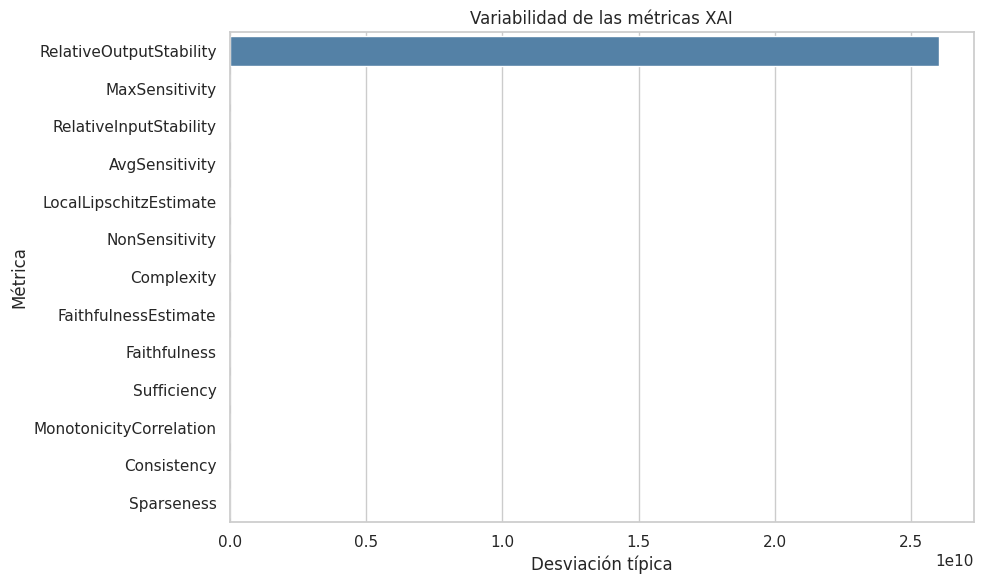

In [7]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=summary_plot.reset_index(),
    y="index",
    x="std",
    color="steelblue"
)

plt.title("Variabilidad de las métricas XAI")
plt.xlabel("Desviación típica")
plt.ylabel("Métrica")
plt.tight_layout()
plt.show()

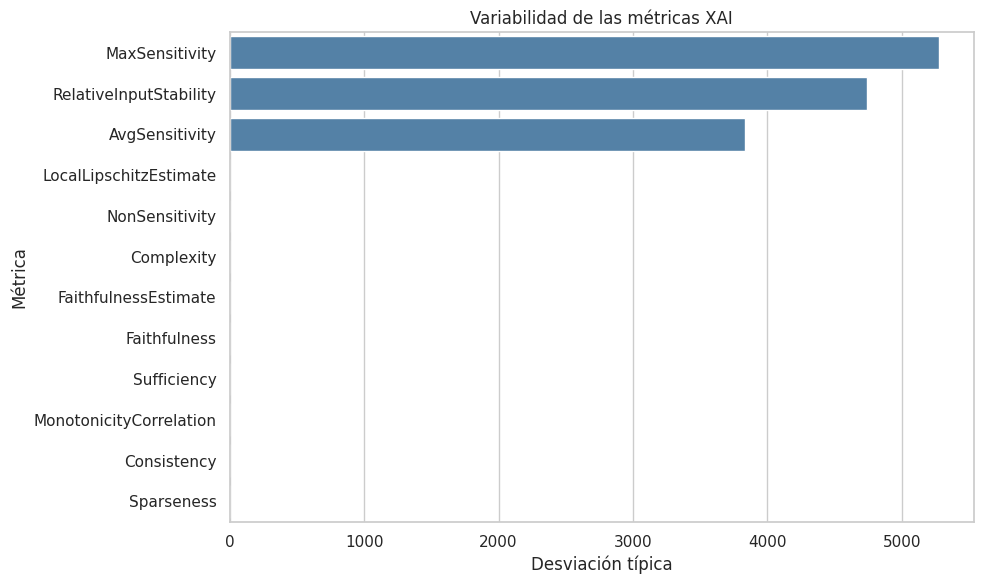

In [8]:
summary_plot_aux = summary_plot.drop(index=['RelativeOutputStability'])
plt.figure(figsize=(10, 6))

sns.barplot(
    data=summary_plot_aux.reset_index(),
    y="index",
    x="std",
    color="steelblue"
)

plt.title("Variabilidad de las métricas XAI")
plt.xlabel("Desviación típica")
plt.ylabel("Métrica")
plt.tight_layout()
plt.show()

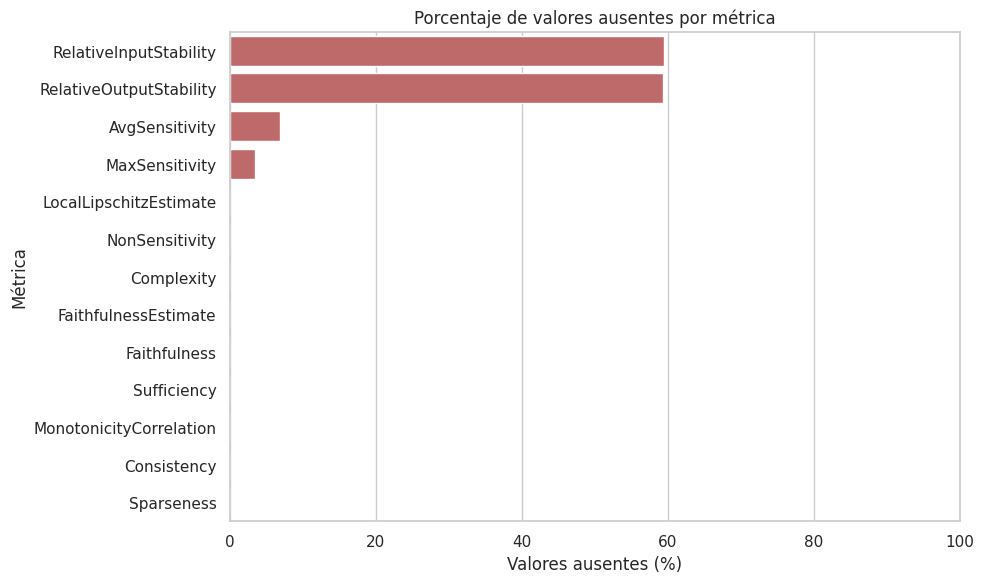

In [9]:
missing_plot = summary_plot.sort_values("missing_pct", ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=missing_plot.reset_index(),
    y="index",
    x="missing_pct",
    color="indianred"
)

plt.title("Porcentaje de valores ausentes por métrica")
plt.xlabel("Valores ausentes (%)")
plt.ylabel("Métrica")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

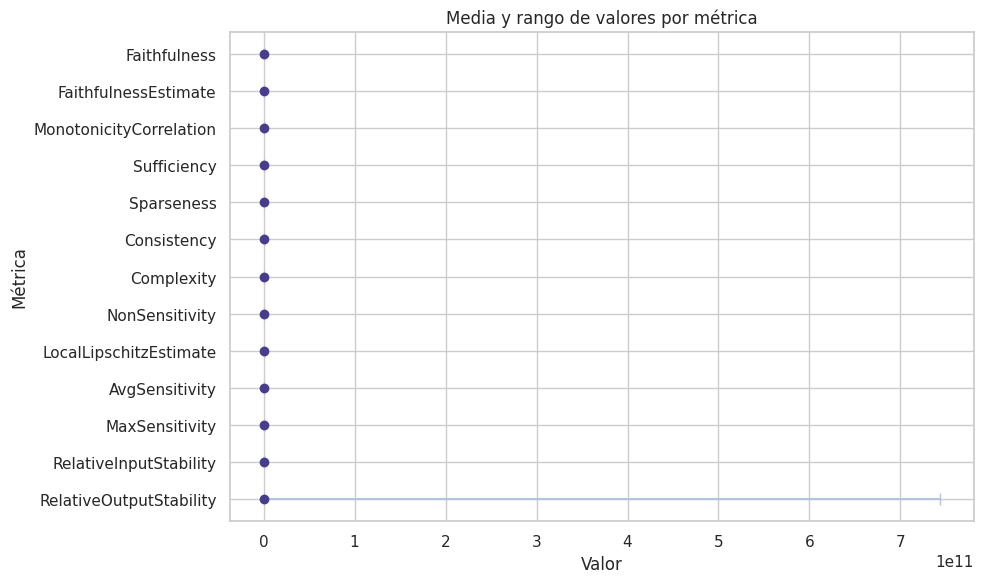

In [10]:
range_plot = summary_plot.sort_values("mean", ascending=False).reset_index()

plt.figure(figsize=(10, 6))

plt.errorbar(
    x=range_plot["mean"],
    y=range_plot["index"],
    xerr=[
        range_plot["mean"] - range_plot["min"],
        range_plot["max"] - range_plot["mean"]
    ],
    fmt="o",
    color="darkslateblue",
    ecolor="lightsteelblue",
    capsize=4
)

plt.title("Media y rango de valores por métrica")
plt.xlabel("Valor")
plt.ylabel("Métrica")
plt.tight_layout()
plt.show()

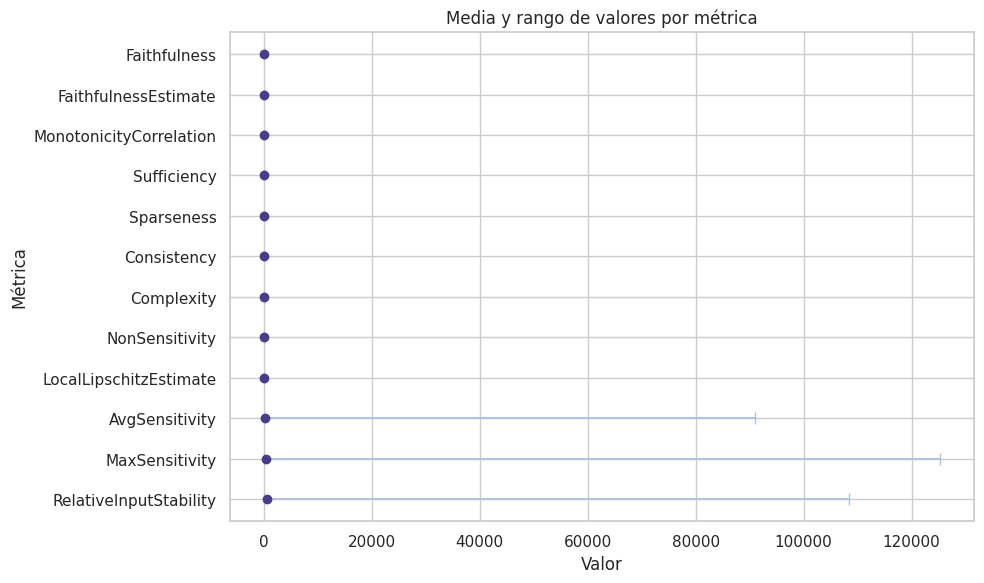

In [11]:
range_plot = summary_plot_aux.sort_values("mean", ascending=False).reset_index()

plt.figure(figsize=(10, 6))

plt.errorbar(
    x=range_plot["mean"],
    y=range_plot["index"],
    xerr=[
        range_plot["mean"] - range_plot["min"],
        range_plot["max"] - range_plot["mean"]
    ],
    fmt="o",
    color="darkslateblue",
    ecolor="lightsteelblue",
    capsize=4
)

plt.title("Media y rango de valores por métrica")
plt.xlabel("Valor")
plt.ylabel("Métrica")
plt.tight_layout()
plt.show()

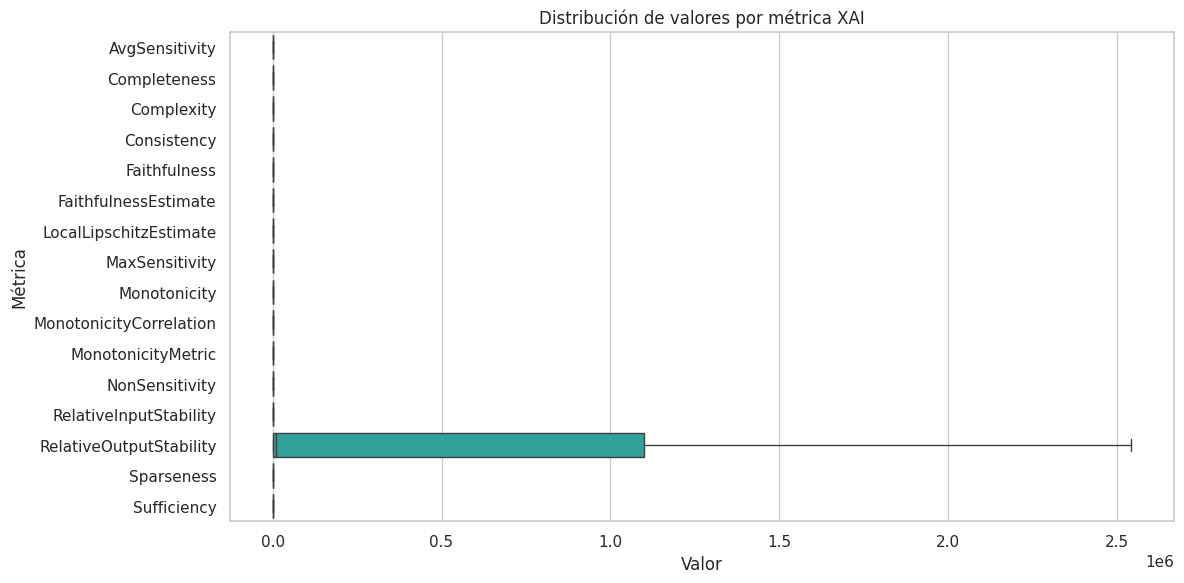

In [12]:
metric_cols_individual = [
    c for c in metric_cols
    if c not in global_metrics
]

plot_df = analysis_df[metric_cols_individual].copy()

for col in metric_cols_individual:
    plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

plot_long = plot_df.melt(
    var_name="metric",
    value_name="value"
).dropna()

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=plot_long,
    x="value",
    y="metric",
    color="lightseagreen",
    showfliers=False
)

plt.title("Distribución de valores por métrica XAI")
plt.xlabel("Valor")
plt.ylabel("Métrica")
plt.tight_layout()
plt.show()

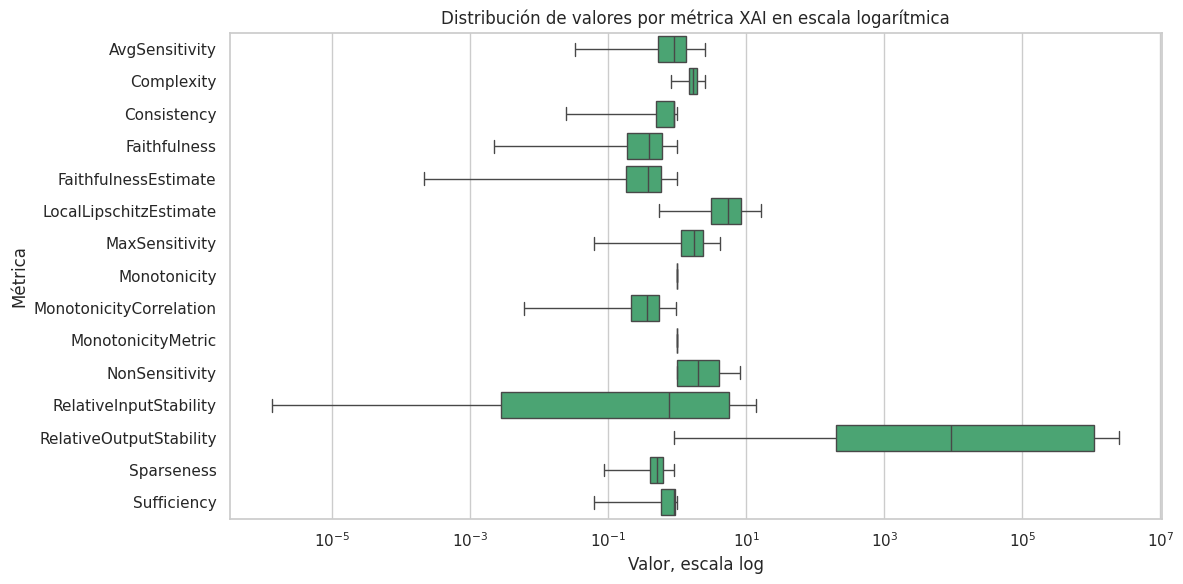

In [13]:
plot_long_positive = plot_long[plot_long["value"] > 0].copy()

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=plot_long_positive,
    x="value",
    y="metric",
    color="mediumseagreen",
    showfliers=False
)

plt.xscale("log")
plt.title("Distribución de valores por métrica XAI en escala logarítmica")
plt.xlabel("Valor, escala log")
plt.ylabel("Métrica")
plt.tight_layout()
plt.show()

## Correlación entre métricas

In [14]:
metric_cols = [
    c for c in analysis_df.columns
    if c not in id_cols and c not in global_metrics
]

for col in metric_cols:
    analysis_df[col] = pd.to_numeric(analysis_df[col], errors='coerce')

X = analysis_df[metric_cols].dropna(axis=0, how='any')

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=metric_cols,
    index=X.index
)

corr = X_scaled.corr(method='spearman')

corr

,AvgSensitivity,Completeness,Complexity,Consistency,Faithfulness,FaithfulnessEstimate,LocalLipschitzEstimate,MaxSensitivity,Monotonicity,MonotonicityCorrelation,MonotonicityMetric,NonSensitivity,RelativeInputStability,RelativeOutputStability,Sparseness,Sufficiency
AvgSensitivity,1.000000,NaN,0.083210,0.265809,-0.164618,-0.031329,0.420919,0.880495,-0.056991,-0.055720,-0.133515,0.428621,0.068727,0.365614,0.127337,-0.105543
Completeness,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Complexity,0.083210,NaN,1.000000,-0.500801,0.051385,0.143451,-0.059807,-0.033162,0.081346,-0.299006,0.007748,-0.151650,-0.174178,-0.411899,-0.788286,0.445042
Consistency,0.265809,NaN,-0.500801,1.000000,-0.360326,-0.118006,0.001909,0.343073,-0.345112,0.344115,-0.209229,0.217362,0.040602,0.485396,0.465035,-0.104172
Faithfulness,-0.164618,NaN,0.051385,-0.360326,1.000000,0.001123,-0.022384,-0.211299,0.197899,-0.101347,0.216304,-0.117346,-0.040083,-0.212686,-0.125097,-0.092099
FaithfulnessEstimate,-0.031329,NaN,0.143451,-0.118006,0.001123,1.000000,-0.015250,-0.054007,0.039879,-0.094717,0.052790,-0.143534,0.093755,-0.060114,-0.134102,0.166001
LocalLipschitzEstimate,0.420919,NaN,-0.059807,0.001909,-0.022384,-0.015250,1.000000,0.251111,0.021192,0.000735,0.059293,0.171636,0.252431,0.266436,0.014986,-0.007001
MaxSensitivity,0.880495,NaN,-0.033162,0.343073,-0.211299,-0.054007,0.251111,1.000000,0.036889,0.000323,-0.108265,0.396548,-0.011067,0.271828,0.184674,-0.138697
Monotonicity,-0.056991,NaN,0.081346,-0.345112,0.197899,0.039879,0.021192,0.036889,1.000000,-0.064961,0.076304,0.110540,-0.177733,-0.412076,-0.137290,0.020371
MonotonicityCorrelation,-0.055720,NaN,-0.299006,0.344115,-0.101347,-0.094717,0.000735,0.000323,-0.064961,1.000000,-0.058121,0.069654,-0.094230,0.095755,0.312037,-0.046545


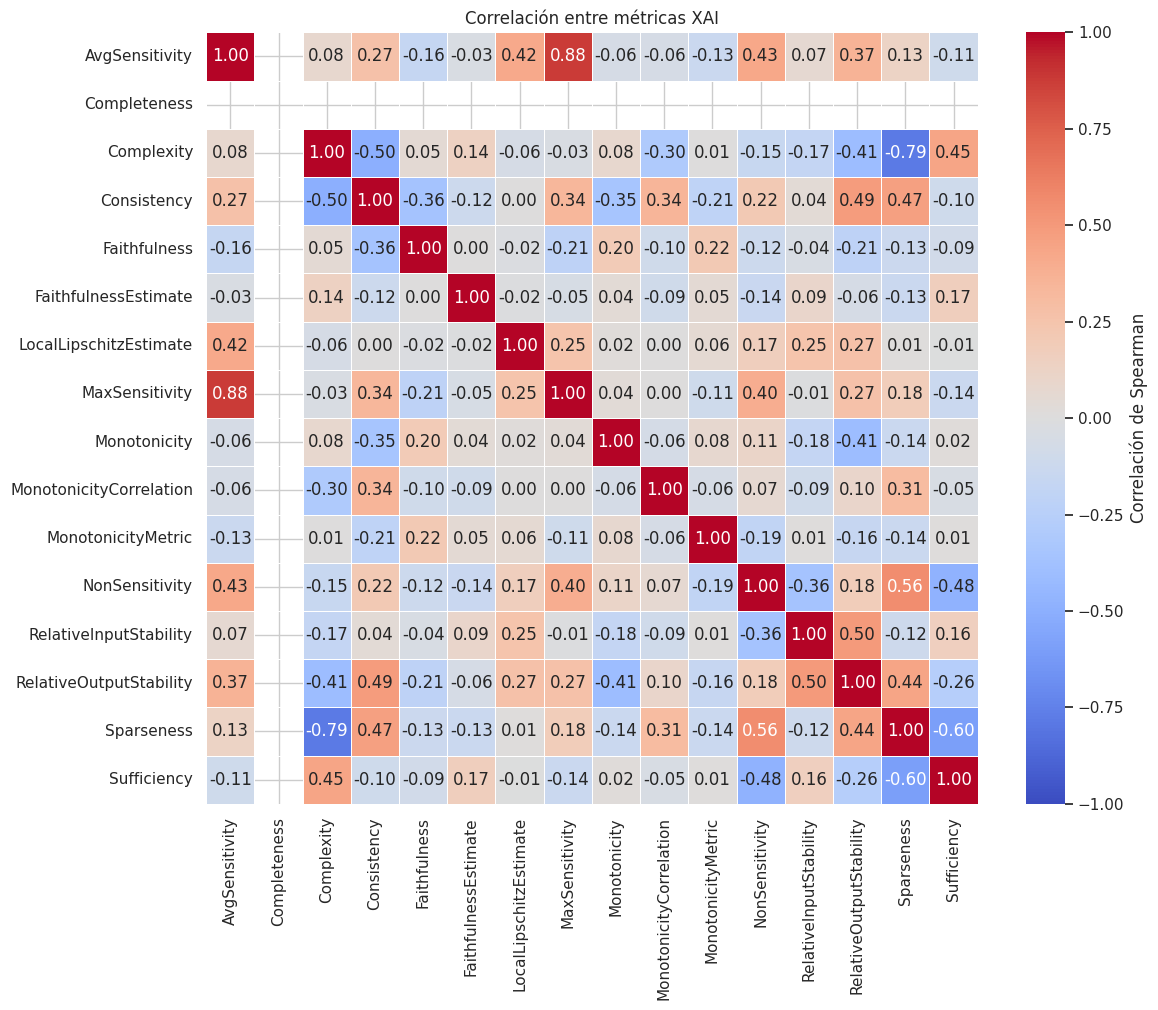

In [15]:
output_dir = Path("results/conclusions_obs_results")
output_dir.mkdir(exist_ok=True)

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr,
    vmin=-1,
    vmax=1,
    center=0,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Correlación de Spearman"}
)

plt.title("Correlación entre métricas XAI")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(output_dir / "correlation_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
corr_pairs = (
    corr.where(~pd.DataFrame(
        [[i >= j for j in range(len(corr.columns))] for i in range(len(corr.index))],
        index=corr.index,
        columns=corr.columns
    ))
    .stack()
    .reset_index()
)

corr_pairs.columns = ["metric_1", "metric_2", "spearman_corr"]
corr_pairs["abs_corr"] = corr_pairs["spearman_corr"].abs()

strong_corr = corr_pairs[
    corr_pairs["abs_corr"] > 0.7
].sort_values("abs_corr", ascending=False)

strong_corr

,metric_1,metric_2,spearman_corr,abs_corr
5,AvgSensitivity,MaxSensitivity,0.880495,0.880495
25,Complexity,Sparseness,-0.788286,0.788286


In [17]:
mean_abs_corr = corr.abs().copy()

for col in mean_abs_corr.columns:
    mean_abs_corr.loc[col, col] = pd.NA

independence_summary = (
    mean_abs_corr.mean(axis=1)
    .sort_values()
    .reset_index()
)

independence_summary.columns = ["metric", "mean_abs_correlation"]

independence_summary

,metric,mean_abs_correlation
0,FaithfulnessEstimate,0.082004
1,MonotonicityMetric,0.102153
2,LocalLipschitzEstimate,0.111792
3,MonotonicityCorrelation,0.116948
4,Monotonicity,0.127042
5,Faithfulness,0.136714
6,RelativeInputStability,0.149615
7,Sufficiency,0.188604
8,MaxSensitivity,0.208674
9,AvgSensitivity,0.227746


## Clustering jerárquico de métricas

In [18]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

In [19]:
Path('results').mkdir(exist_ok=True)

corr_cluster = corr.copy()

corr_cluster = corr_cluster.dropna(axis=0, how='all').dropna(axis=1, how='all')

valid_metrics = corr_cluster.index.intersection(corr_cluster.columns)
corr_cluster = corr_cluster.loc[valid_metrics, valid_metrics]

corr_cluster = corr_cluster.fillna(0)

distance = 1 - corr_cluster.abs()
np.fill_diagonal(distance.values, 0)

linkage_matrix = linkage(
    squareform(distance),
    method='average'
)

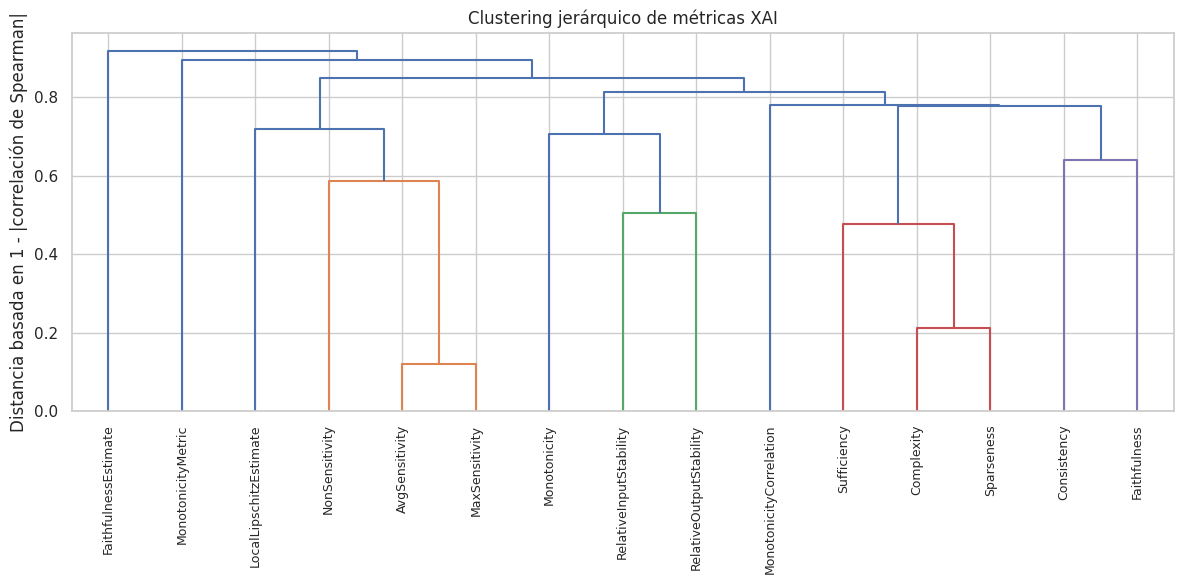

In [20]:
output_dir = Path("results/conclusions_obs_results")
output_dir.mkdir(exist_ok=True)

plt.figure(figsize=(12, 6))

dendrogram(
    linkage_matrix,
    labels=corr_cluster.columns,
    leaf_rotation=90,
    leaf_font_size=9
)

plt.title("Clustering jerárquico de métricas XAI")
plt.ylabel("Distancia basada en 1 - |correlación de Spearman|")
plt.tight_layout()
plt.savefig(output_dir / "dendrogram_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

## Influencia de dataset, modelo y método XAI

In [21]:
from scipy.stats import kruskal

In [22]:
sns.set_theme(style='whitegrid', context='notebook')

results_dir = Path("results/conclusions_obs_results")
results_dir.mkdir(exist_ok=True)

metric_cols = [
    c for c in analysis_df.columns
    if c not in id_cols and c not in global_metrics
]

for col in metric_cols:
    analysis_df[col] = pd.to_numeric(analysis_df[col], errors='coerce')

factors = ["dataset_name", "model_name", "xai_method"]

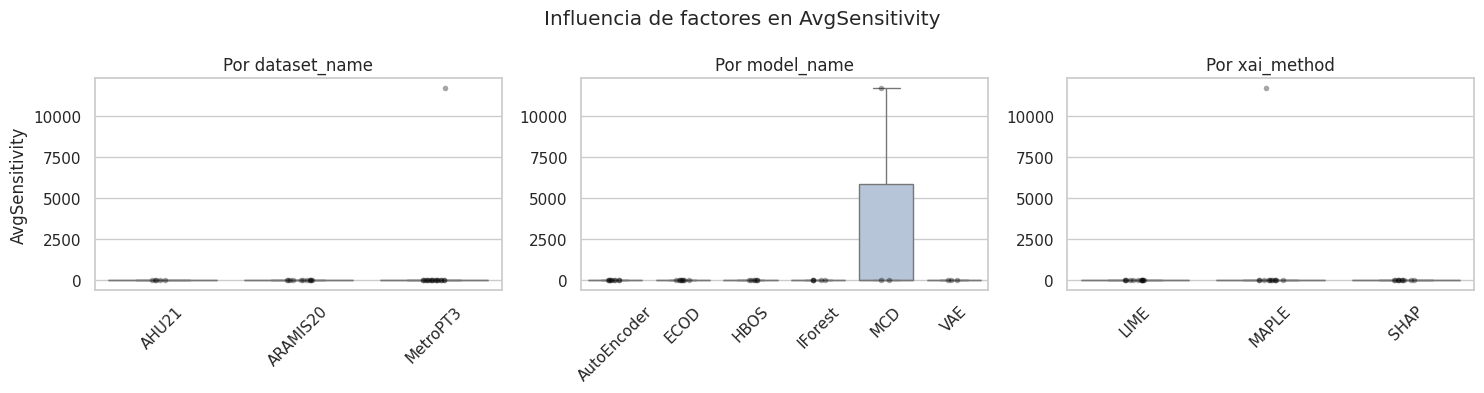

Saltando Completeness: no tiene variabilidad suficiente.


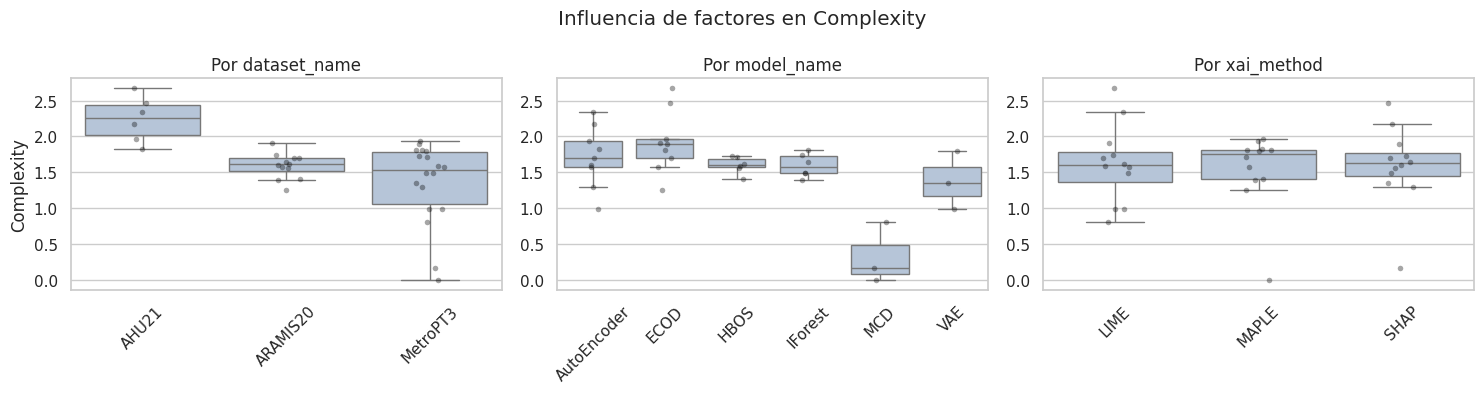

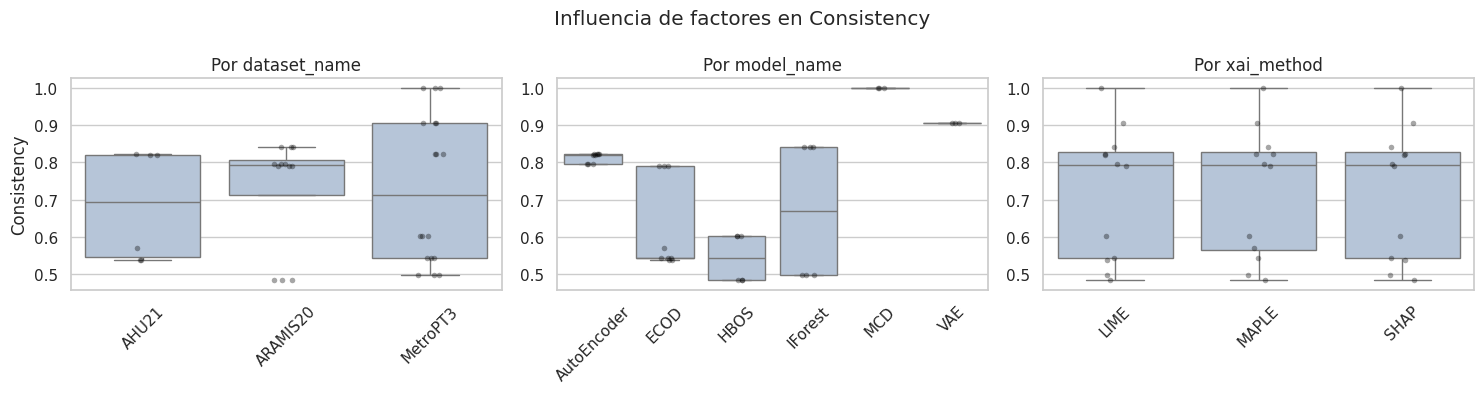

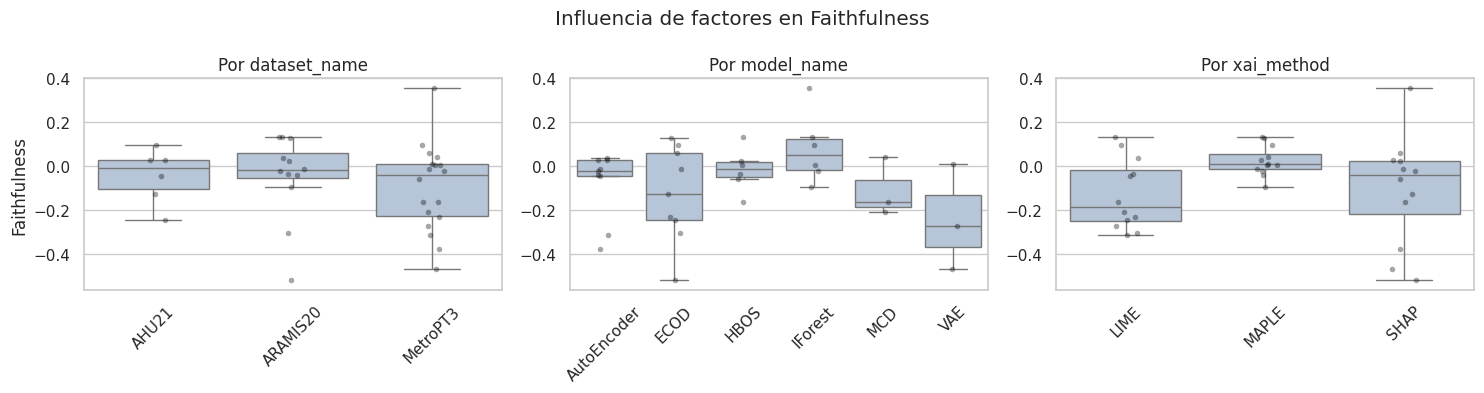

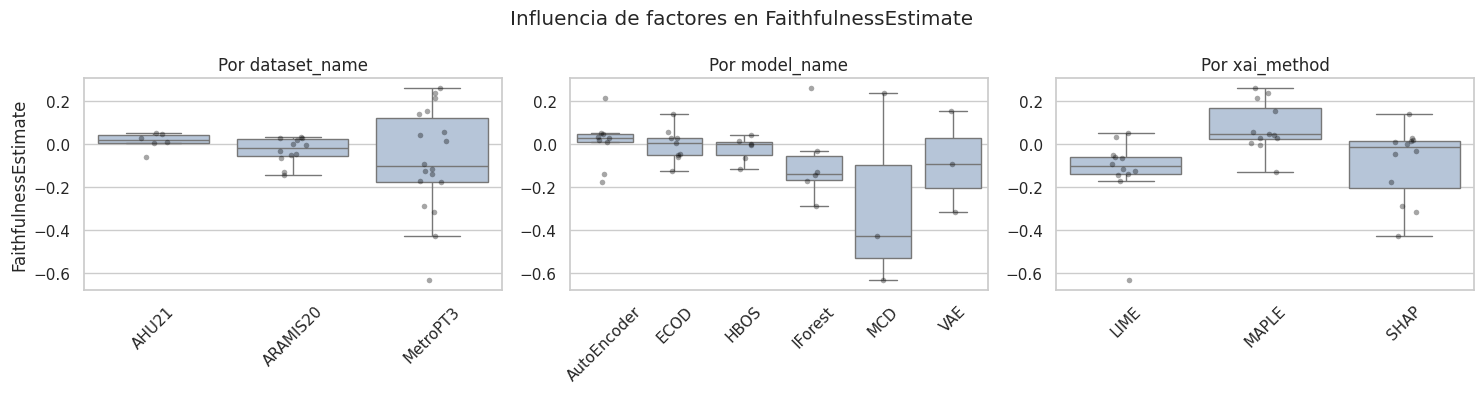

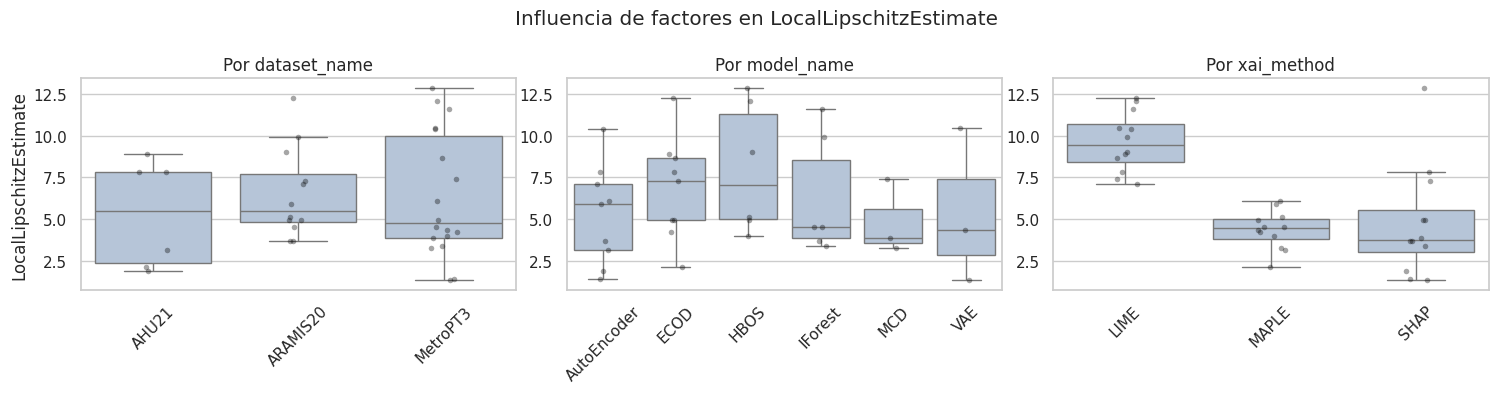

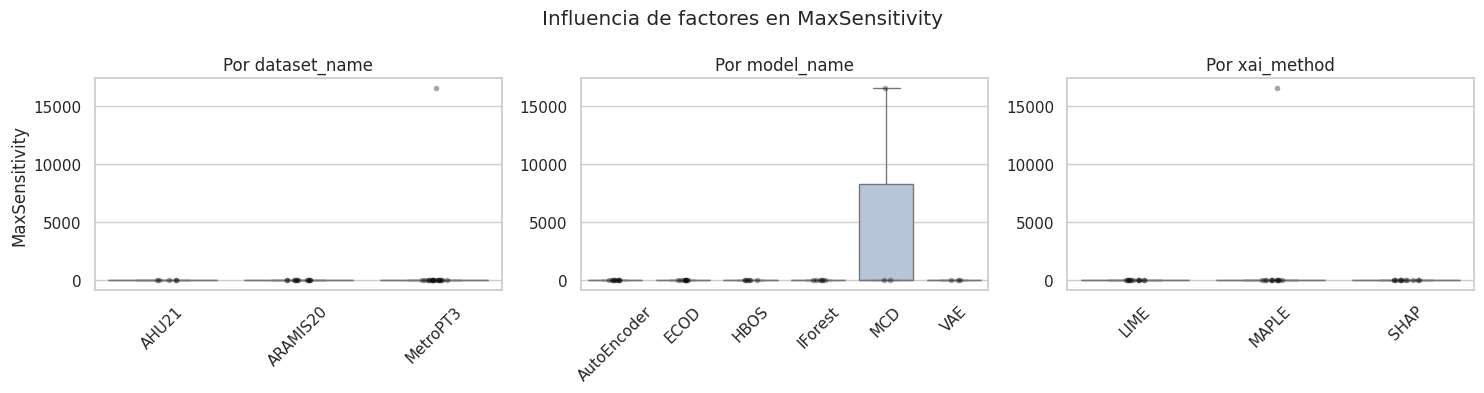

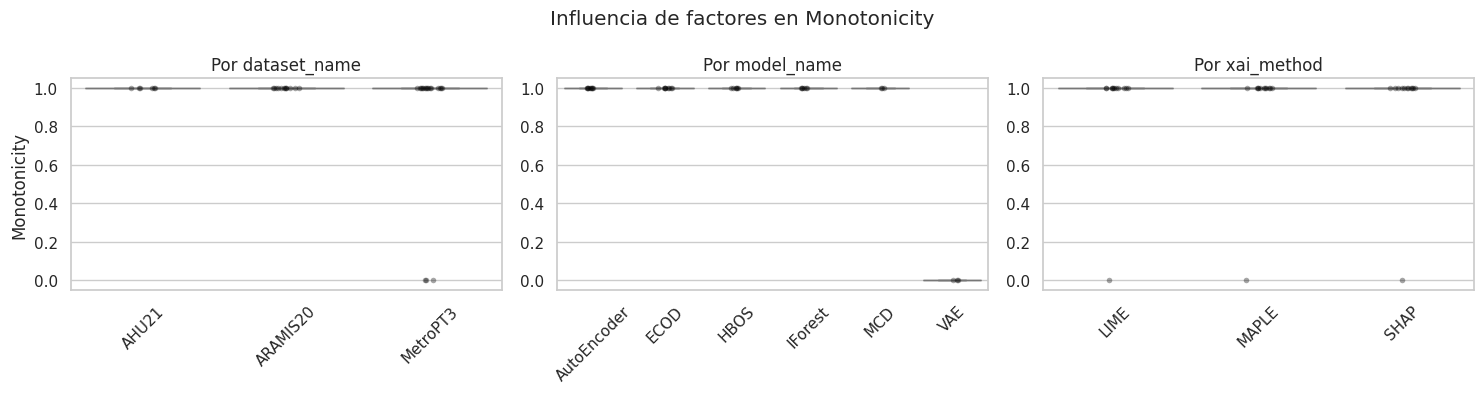

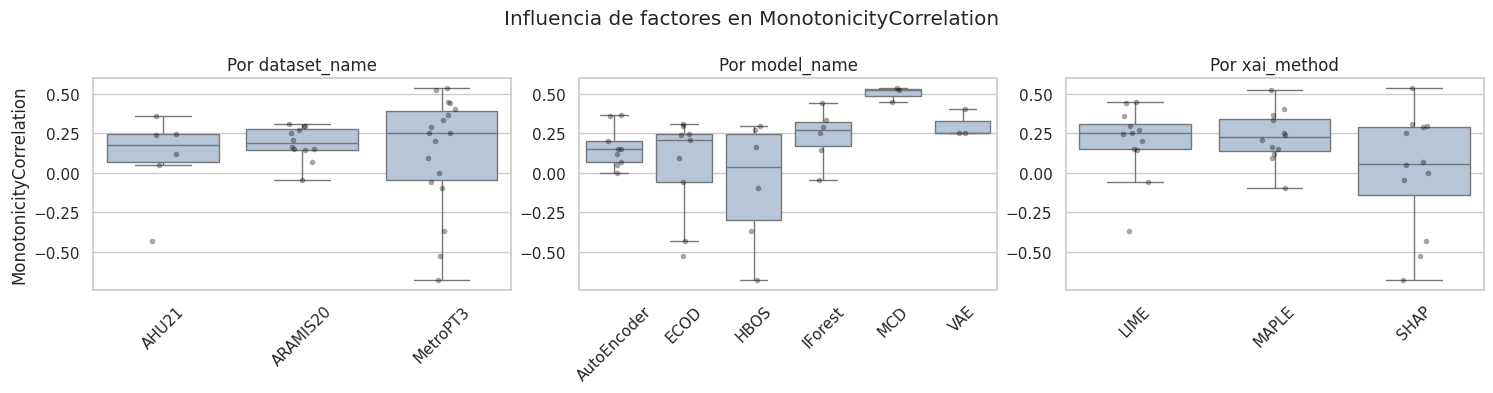

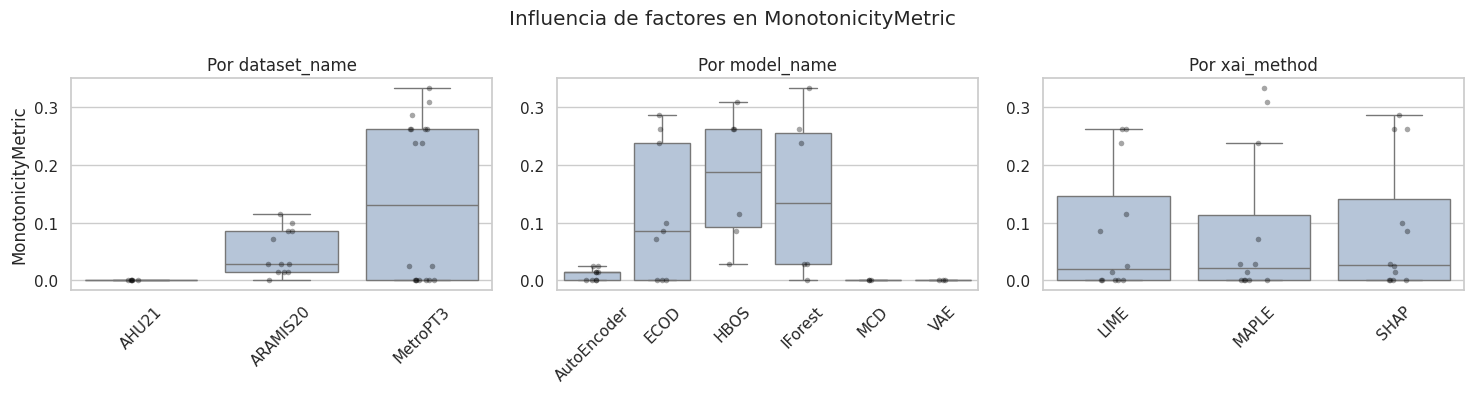

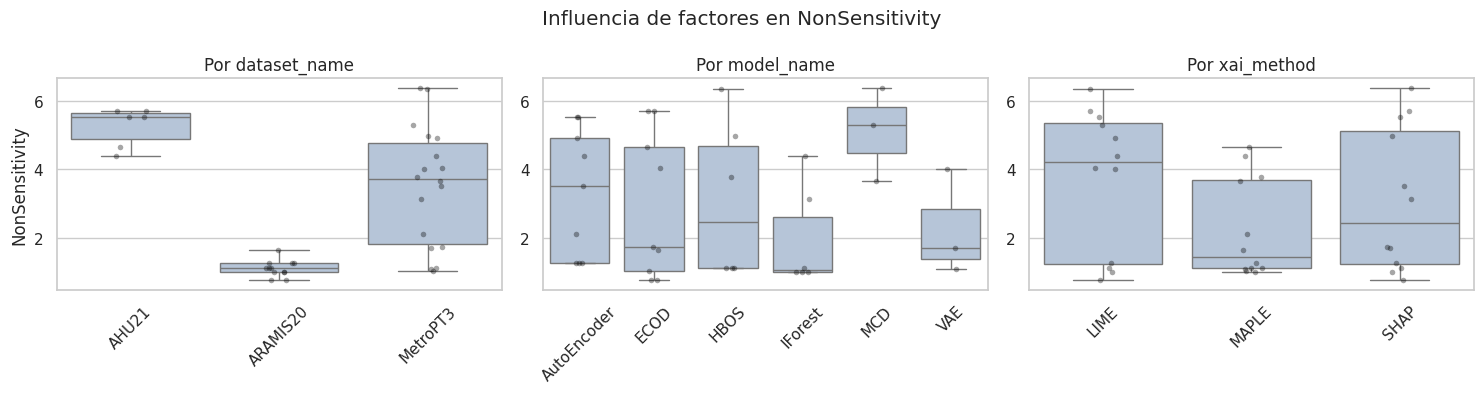

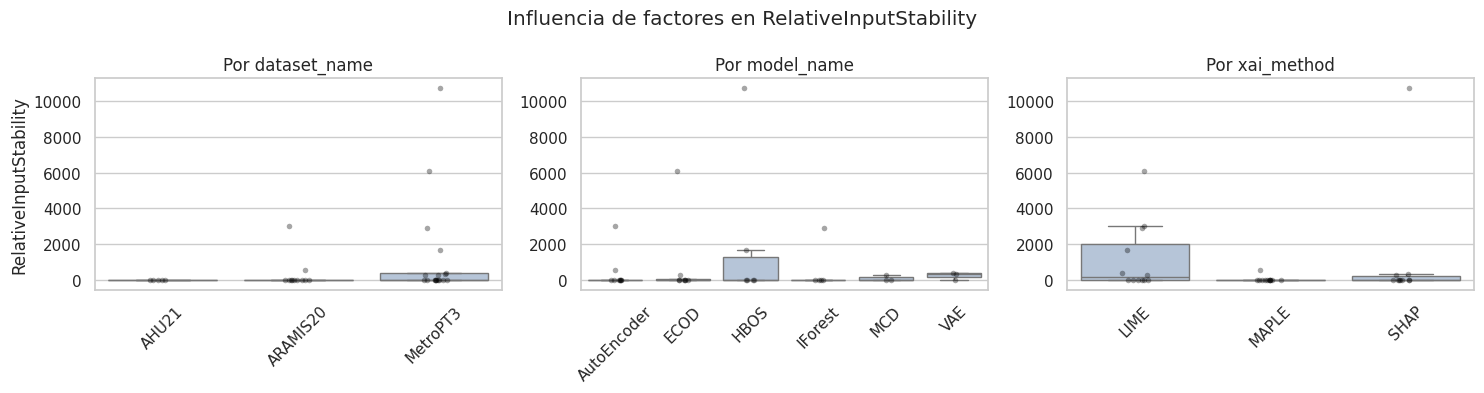

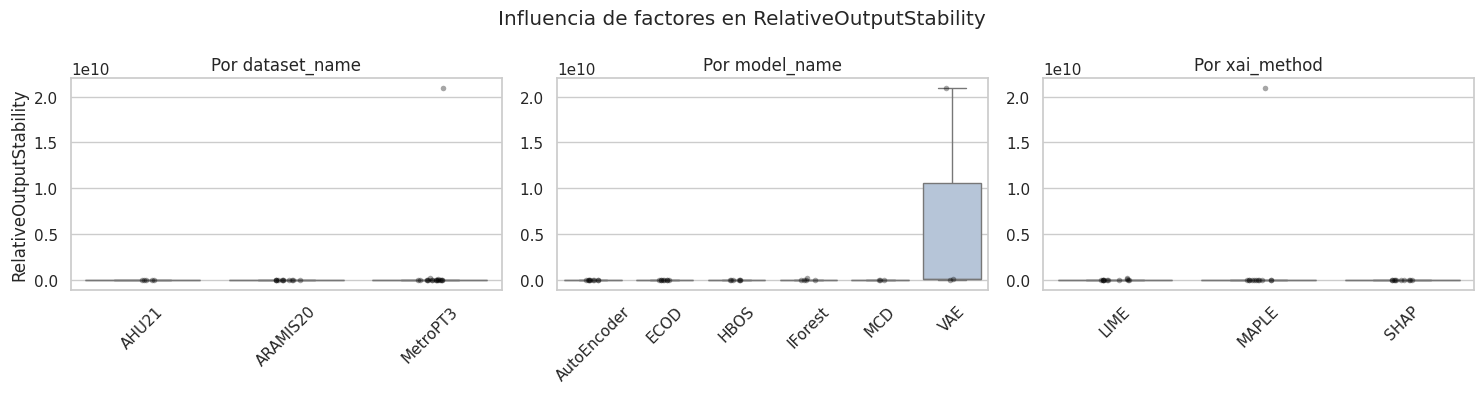

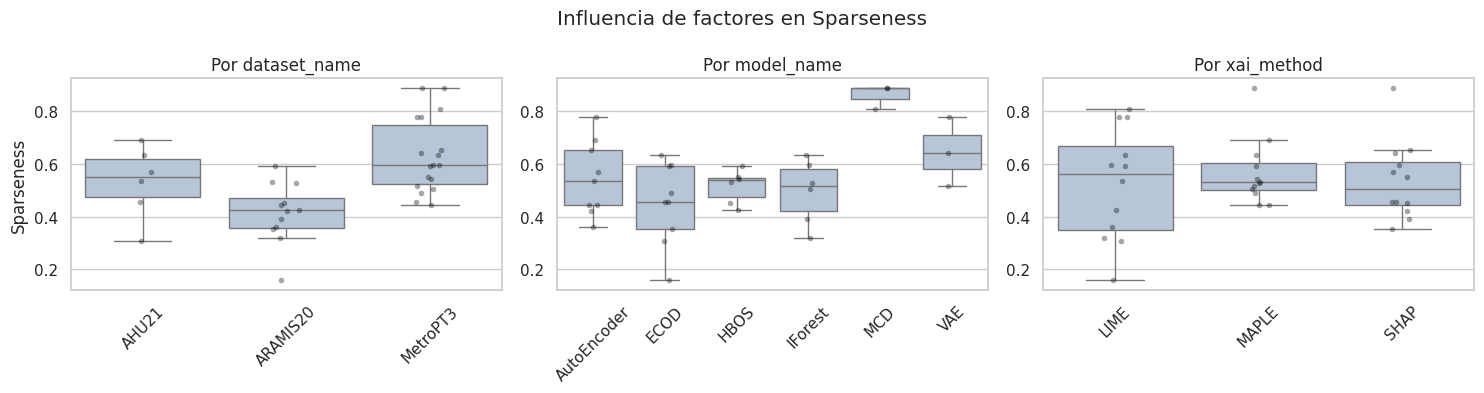

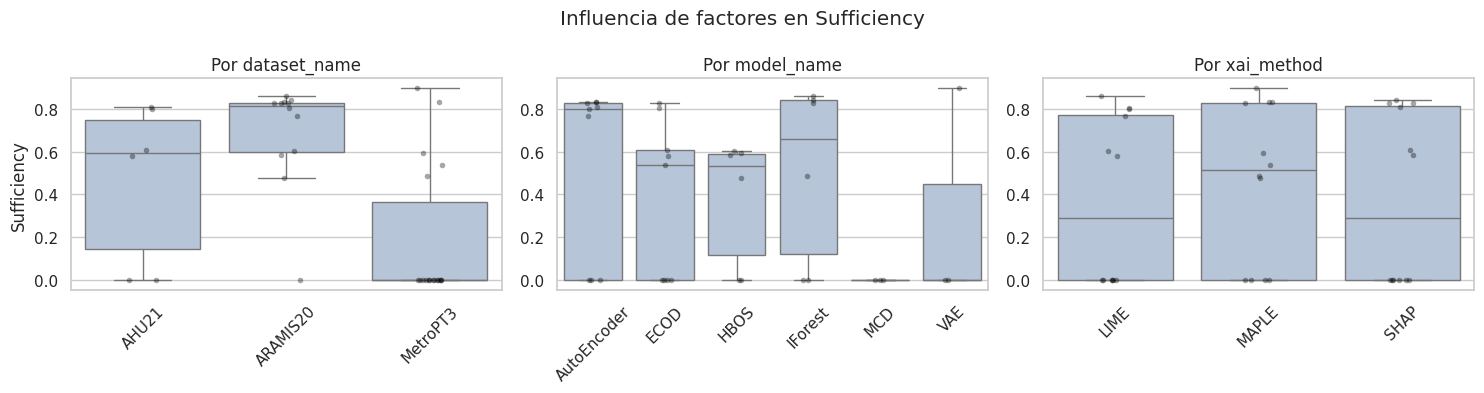

In [23]:
for metric in metric_cols:
    if analysis_df[metric].dropna().nunique() <= 1:
        print(f"Saltando {metric}: no tiene variabilidad suficiente.")
        continue

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for ax, factor in zip(axes, factors):
        plot_df = analysis_agg_df[[factor, metric]].dropna()

        sns.boxplot(
            data=plot_df,
            x=factor,
            y=metric,
            ax=ax,
            color="lightsteelblue",
            showfliers=False
        )

        sns.stripplot(
            data=plot_df,
            x=factor,
            y=metric,
            ax=ax,
            color="black",
            alpha=0.35,
            size=4,
            jitter=True
        )

        ax.set_title(f"Por {factor}")
        ax.set_xlabel("")
        ax.set_ylabel(metric if factor == factors[0] else "")
        ax.tick_params(axis="x", rotation=45)

    fig.suptitle(f"Influencia de factores en {metric}")
    plt.tight_layout()
    plt.savefig(results_dir / f"{metric}_factors_boxplots.png", dpi=300, bbox_inches="tight")
    plt.show()

In [24]:
kruskal_results = []

for metric in metric_cols:
    if analysis_df[metric].dropna().nunique() <= 1:
        continue

    for factor in factors:
        groups = [
            group[metric].dropna().values
            for _, group in analysis_df.groupby(factor)
        ]

        groups = [g for g in groups if len(g) > 0]

        if len(groups) > 1:
            stat, p_value = kruskal(*groups)

            kruskal_results.append({
                "metric": metric,
                "factor": factor,
                "H": stat,
                "p_value": p_value,
                "significant_0.05": p_value < 0.05
            })

kruskal_df = pd.DataFrame(kruskal_results)

kruskal_df = kruskal_df.sort_values(
    ["p_value", "metric", "factor"],
    ascending=[True, True, True]
)

kruskal_df

,metric,factor,H,p_value,significant_0.05
22,Monotonicity,model_name,2015.000000,0.000000e+00,True
30,NonSensitivity,dataset_name,1153.357120,3.561914e-251,True
7,Consistency,model_name,833.765078,5.730067e-178,True
17,LocalLipschitzEstimate,xai_method,727.036445,1.336725e-158,True
3,Complexity,dataset_name,669.058135,5.198427e-146,True
42,Sufficiency,dataset_name,564.663480,2.425958e-123,True
39,Sparseness,dataset_name,562.965884,5.669065e-123,True
4,Complexity,model_name,568.527517,1.273661e-120,True
40,Sparseness,model_name,483.991178,2.277273e-102,True
36,RelativeOutputStability,dataset_name,322.038587,1.175464e-70,True


In [25]:
kruskal_summary = kruskal_df.copy()

kruskal_summary["p_value"] = kruskal_summary["p_value"].round(4)
kruskal_summary["H"] = kruskal_summary["H"].round(3)

kruskal_summary

,metric,factor,H,p_value,significant_0.05
22,Monotonicity,model_name,2015.000,0.0000,True
30,NonSensitivity,dataset_name,1153.357,0.0000,True
7,Consistency,model_name,833.765,0.0000,True
17,LocalLipschitzEstimate,xai_method,727.036,0.0000,True
3,Complexity,dataset_name,669.058,0.0000,True
42,Sufficiency,dataset_name,564.663,0.0000,True
39,Sparseness,dataset_name,562.966,0.0000,True
4,Complexity,model_name,568.528,0.0000,True
40,Sparseness,model_name,483.991,0.0000,True
36,RelativeOutputStability,dataset_name,322.039,0.0000,True


In [26]:
kruskal_summary.to_csv(
    results_dir / "kruskal_metric_factors.csv",
    index=False
)

## PCA

In [27]:
from sklearn.decomposition import PCA

In [28]:
metric_cols = [
    c for c in analysis_df.columns
    if c not in id_cols and c not in global_metrics
]

for col in metric_cols:
    analysis_df[col] = pd.to_numeric(analysis_df[col], errors="coerce")

valid_metric_cols = [
    c for c in metric_cols
    if analysis_df[c].dropna().nunique() > 1
]

X = analysis_df[valid_metric_cols].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca.explained_variance_ratio_)
})

explained_variance

,component,explained_variance_ratio,cumulative_variance
0,PC1,0.199428,0.199428
1,PC2,0.131674,0.331102
2,PC3,0.112398,0.443500
3,PC4,0.079072,0.522572
4,PC5,0.073058,0.595631
5,PC6,0.067559,0.663190
6,PC7,0.064617,0.727807
7,PC8,0.061416,0.789223
8,PC9,0.059265,0.848488
9,PC10,0.049730,0.898218


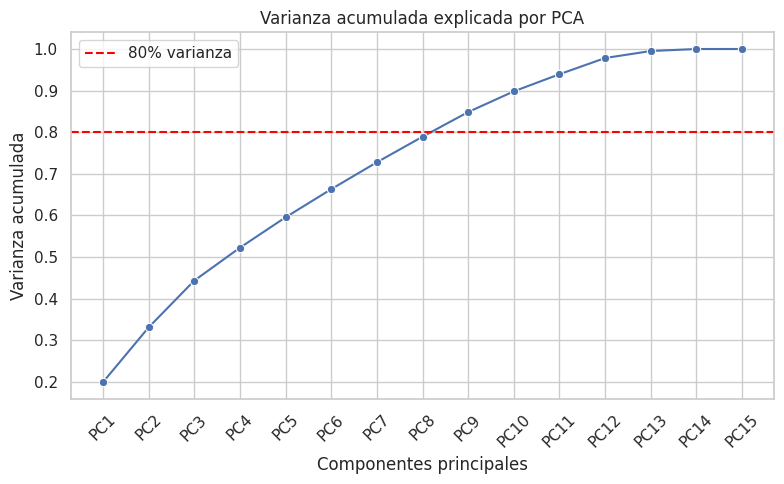

In [29]:
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=explained_variance,
    x="component",
    y="cumulative_variance",
    marker="o"
)

plt.axhline(0.8, color="red", linestyle="--", label="80% varianza")
plt.title("Varianza acumulada explicada por PCA")
plt.xlabel("Componentes principales")
plt.ylabel("Varianza acumulada")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "pca_explained_variance.png", dpi=300, bbox_inches="tight")
plt.show()

In [30]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=valid_metric_cols,
    columns=[f"PC{i+1}" for i in range(len(valid_metric_cols))]
)

loadings.iloc[:, :3].sort_values("PC1", key=abs, ascending=False)

,PC1,PC2,PC3
Sparseness,0.504826,-0.129323,-0.212356
Complexity,-0.474717,0.004460,0.129535
Consistency,0.329402,-0.174366,0.442781
Sufficiency,-0.282432,0.024761,0.514067
MonotonicityCorrelation,0.258576,-0.048285,0.099963
MaxSensitivity,0.247712,0.617243,0.113590
AvgSensitivity,0.246690,0.617705,0.114100
NonSensitivity,0.244326,-0.251302,-0.190332
Faithfulness,-0.181629,0.206007,-0.425580
MonotonicityMetric,-0.140849,0.141045,-0.237774


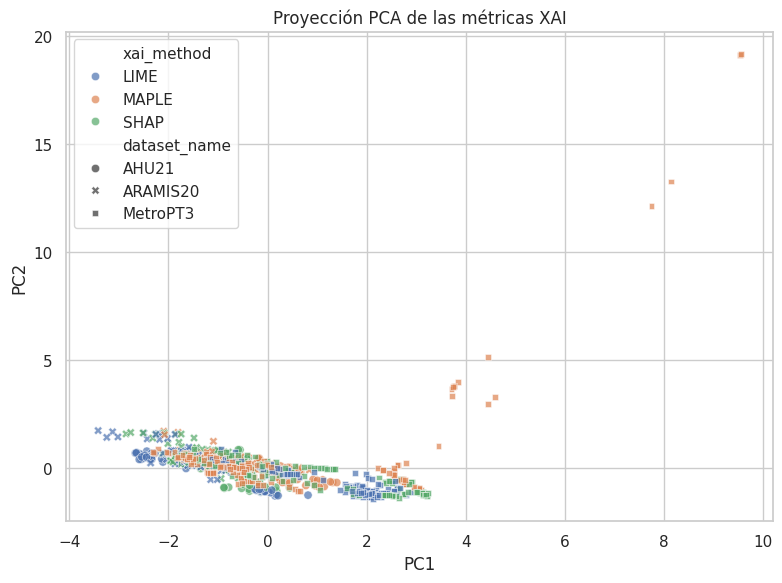

In [31]:
pca_df = pd.DataFrame(
    X_pca[:, :2],
    columns=["PC1", "PC2"],
    index=X.index
)

pca_df = pca_df.join(analysis_df.loc[X.index, ["dataset_name", "model_name", "xai_method"]])

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="xai_method",
    style="dataset_name",
    alpha=0.7
)

plt.title("Proyección PCA de las métricas XAI")
plt.tight_layout()
plt.savefig(output_dir / "pca_metrics_projection.png", dpi=300, bbox_inches="tight")
plt.show()

# Análisis de métricas agregadas

In [32]:
matrix_path = Path("results/metric_analysis_agg_matrix.csv")
analysis_agg_df = pd.read_csv(matrix_path)

id_cols = ['dataset_name', 'model_name', 'xai_method']

results_dir = Path("results/conclusions_agg_results")
results_dir.mkdir(exist_ok=True)

analysis_agg_df.head()

,dataset_name,model_name,xai_method,AvgSensitivity,Completeness,Complexity,Consistency,Faithfulness,FaithfulnessEstimate,LocalLipschitzEstimate,MaxSensitivity,Monotonicity,MonotonicityCorrelation,MonotonicityMetric,NonSensitivity,RelativeInputStability,RelativeOutputStability,SensitivityN,Sparseness,Sufficiency
0,AHU21,AutoEncoder,LIME,1.130820,0.0,2.344844,0.819048,-0.043856,0.052458,7.829960,1.833814,1.0,0.357878,0.0,5.528571,0.000247,502.620107,-0.159482,0.533692,0.796616
1,AHU21,AutoEncoder,MAPLE,0.810518,0.0,1.827839,0.822222,0.025880,0.047933,3.171403,1.727345,1.0,0.119013,0.0,4.385714,0.175526,235580.702307,0.012383,0.688531,0.000000
2,AHU21,AutoEncoder,SHAP,1.631231,0.0,2.167066,0.819048,0.027710,0.008464,1.898171,3.693749,1.0,0.049265,0.0,5.542857,0.001076,972.891420,0.299500,0.569092,0.807427
3,AHU21,ECOD,LIME,1.181565,0.0,2.675365,0.539048,-0.244549,-0.059335,8.920034,1.638609,1.0,0.249230,0.0,5.700000,0.000335,51.994686,-0.180843,0.308223,0.579370
4,AHU21,ECOD,MAPLE,0.834596,0.0,1.967611,0.570794,0.097456,0.004964,2.105741,2.100510,1.0,0.240288,0.0,4.657143,0.000132,29.033082,0.018716,0.634111,0.000000


## Análisis descriptivo de las métricas

In [33]:
metric_cols_agg = [
    c for c in analysis_agg_df.columns
    if c not in id_cols
]

for col in metric_cols_agg:
    analysis_agg_df[col] = pd.to_numeric(analysis_agg_df[col], errors='coerce')

summary_agg = analysis_agg_df[metric_cols_agg].describe().T

summary_agg['missing'] = analysis_agg_df[metric_cols_agg].isna().sum()
summary_agg['missing_pct'] = analysis_agg_df[metric_cols_agg].isna().mean() * 100
summary_agg['std'] = analysis_agg_df[metric_cols_agg].std()
summary_agg['range'] = summary_agg['max'] - summary_agg['min']
summary_agg['n_unique'] = analysis_agg_df[metric_cols_agg].nunique(dropna=True)

summary_agg = summary_agg[
    ['mean', 'std', 'min', 'max', 'range', 'missing', 'missing_pct', 'n_unique']
].sort_values('std', ascending=False)

summary_agg

,mean,std,min,max,range,missing,missing_pct,n_unique
RelativeOutputStability,6.306920e+08,3.588527e+09,2.903308e+01,2.093812e+10,2.093812e+10,2,5.555556,34
MaxSensitivity,4.760156e+02,2.803885e+03,8.099279e-01,1.659008e+04,1.658927e+04,1,2.777778,35
RelativeInputStability,7.785104e+02,2.151143e+03,1.321422e-04,1.072343e+04,1.072343e+04,2,5.555556,34
AvgSensitivity,3.459804e+02,2.010914e+03,5.987122e-01,1.172666e+04,1.172606e+04,2,5.555556,34
LocalLipschitzEstimate,6.247982e+00,3.266120e+00,1.334738e+00,1.286683e+01,1.153209e+01,0,0.000000,36
NonSensitivity,3.000926e+00,1.940292e+00,7.571429e-01,6.380952e+00,5.623810e+00,0,0.000000,29
Complexity,1.584204e+00,5.289464e-01,-1.000089e-12,2.675365e+00,2.675365e+00,0,0.000000,36
Sufficiency,3.995776e-01,3.767931e-01,0.000000e+00,8.971310e-01,8.971310e-01,0,0.000000,21
SensitivityN,-1.551744e-01,3.172265e-01,-9.636733e-01,2.995004e-01,1.263174e+00,0,0.000000,36
MonotonicityCorrelation,1.468291e-01,2.806469e-01,-6.812231e-01,5.389873e-01,1.220210e+00,0,0.000000,36


In [34]:
sns.set_theme(style='whitegrid', context='notebook')

summary_agg_plot = summary_agg.copy()

summary_agg_plot = summary_agg_plot.drop(index=global_metrics, errors='ignore')

summary_agg_plot = summary_agg_plot.sort_values('std', ascending=False)

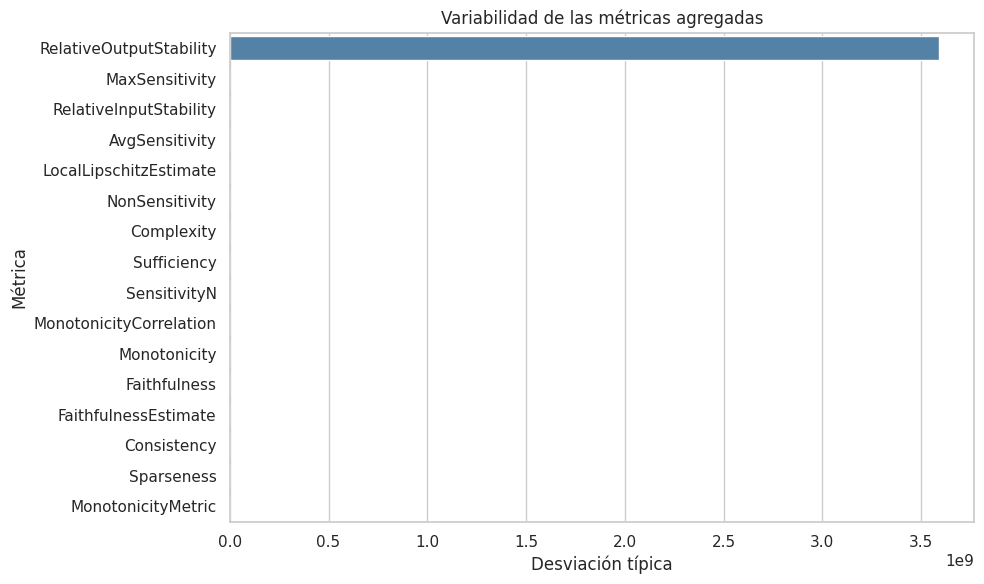

In [35]:
summary_plot_agg = summary_agg[
    summary_agg["n_unique"] > 1
].copy()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=summary_plot_agg.reset_index(),
    y="index",
    x="std",
    color="steelblue"
)
plt.title("Variabilidad de las métricas agregadas")
plt.xlabel("Desviación típica")
plt.ylabel("Métrica")
plt.tight_layout()
plt.savefig(results_dir / "agg_metric_std.png", dpi=300, bbox_inches="tight")
plt.show()

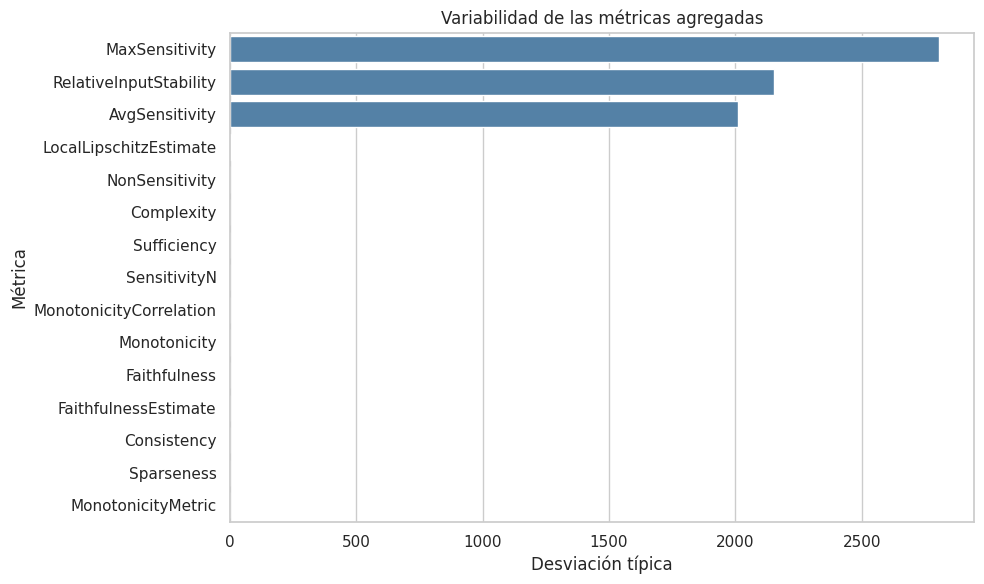

In [36]:
summary_plot_agg = summary_agg[
    summary_agg["n_unique"] > 1
].copy()

summary_plot_agg_aux = summary_plot_agg.drop(index=['RelativeOutputStability'])

plt.figure(figsize=(10, 6))
sns.barplot(
    data=summary_plot_agg_aux.reset_index(),
    y="index",
    x="std",
    color="steelblue"
)
plt.title("Variabilidad de las métricas agregadas")
plt.xlabel("Desviación típica")
plt.ylabel("Métrica")
plt.tight_layout()
plt.savefig(results_dir / "agg_metric_std.png", dpi=300, bbox_inches="tight")
plt.show()

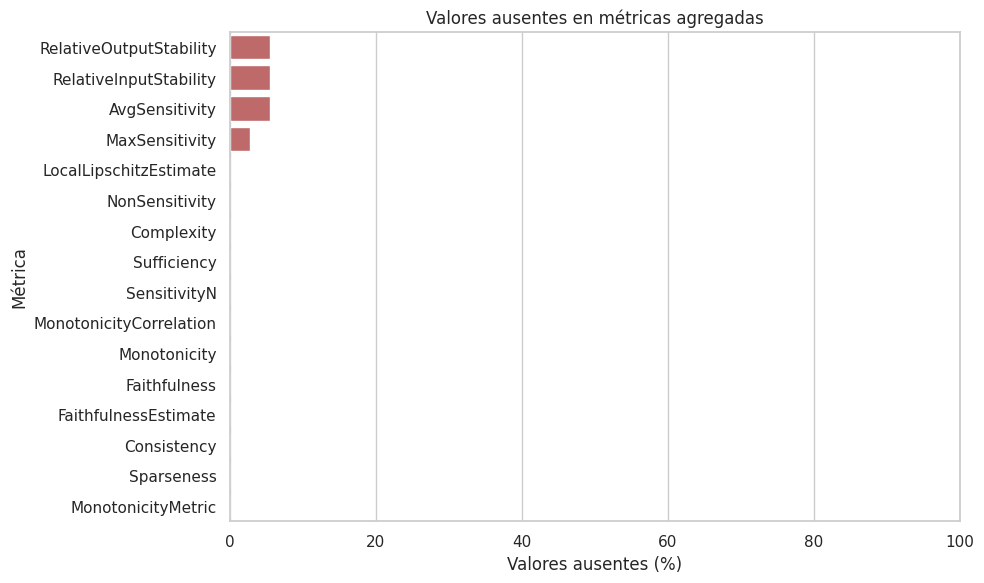

In [37]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=summary_plot_agg.sort_values("missing_pct", ascending=False).reset_index(),
    y="index",
    x="missing_pct",
    color="indianred"
)
plt.title("Valores ausentes en métricas agregadas")
plt.xlabel("Valores ausentes (%)")
plt.ylabel("Métrica")
plt.xlim(0, 100)
plt.tight_layout()
plt.savefig(results_dir / "agg_metric_missing.png", dpi=300, bbox_inches="tight")
plt.show()

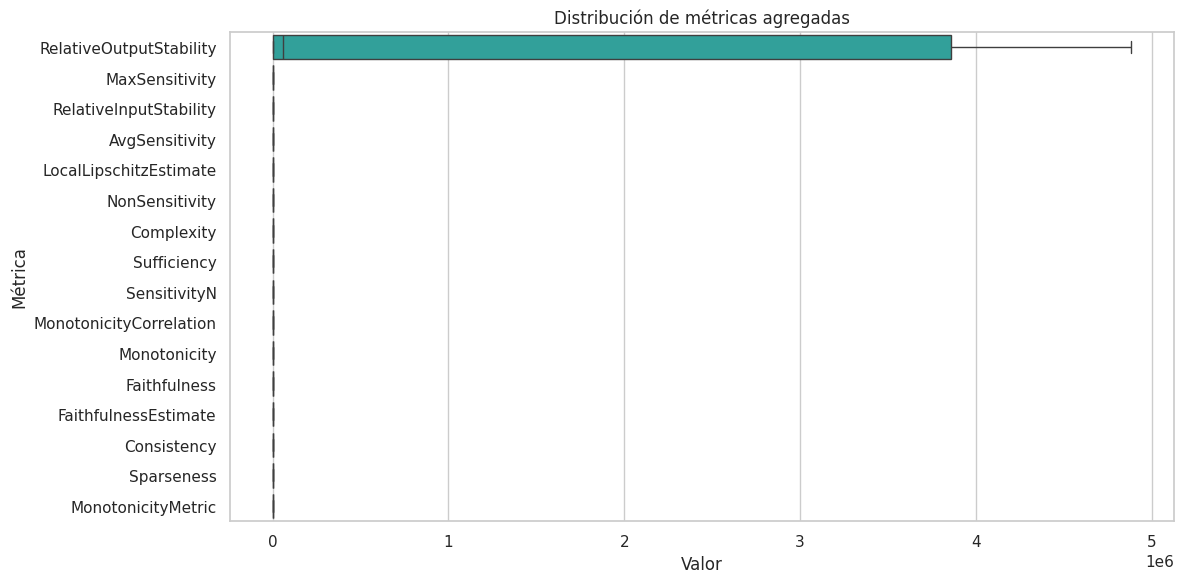

In [38]:
plot_long_agg = analysis_agg_df[summary_plot_agg.index].melt(
    var_name="metric",
    value_name="value"
).dropna()

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=plot_long_agg,
    x="value",
    y="metric",
    color="lightseagreen",
    showfliers=False
)
plt.title("Distribución de métricas agregadas")
plt.xlabel("Valor")
plt.ylabel("Métrica")
plt.tight_layout()
plt.savefig(results_dir / "agg_metric_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

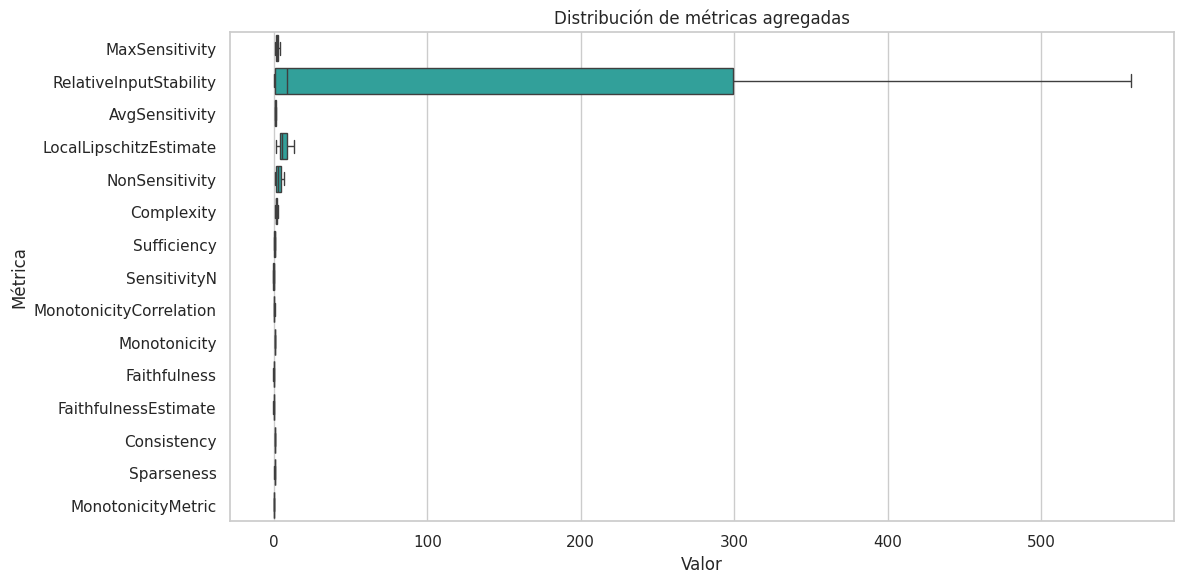

In [39]:
summary_plot_agg_aux = summary_plot_agg.drop(index=['RelativeOutputStability'])

plot_long_agg = analysis_agg_df[summary_plot_agg_aux.index].melt(
    var_name="metric",
    value_name="value"
).dropna()


plt.figure(figsize=(12, 6))
sns.boxplot(
    data=plot_long_agg,
    x="value",
    y="metric",
    color="lightseagreen",
    showfliers=False
)
plt.title("Distribución de métricas agregadas")
plt.xlabel("Valor")
plt.ylabel("Métrica")
plt.tight_layout()
plt.savefig(results_dir / "agg_metric_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

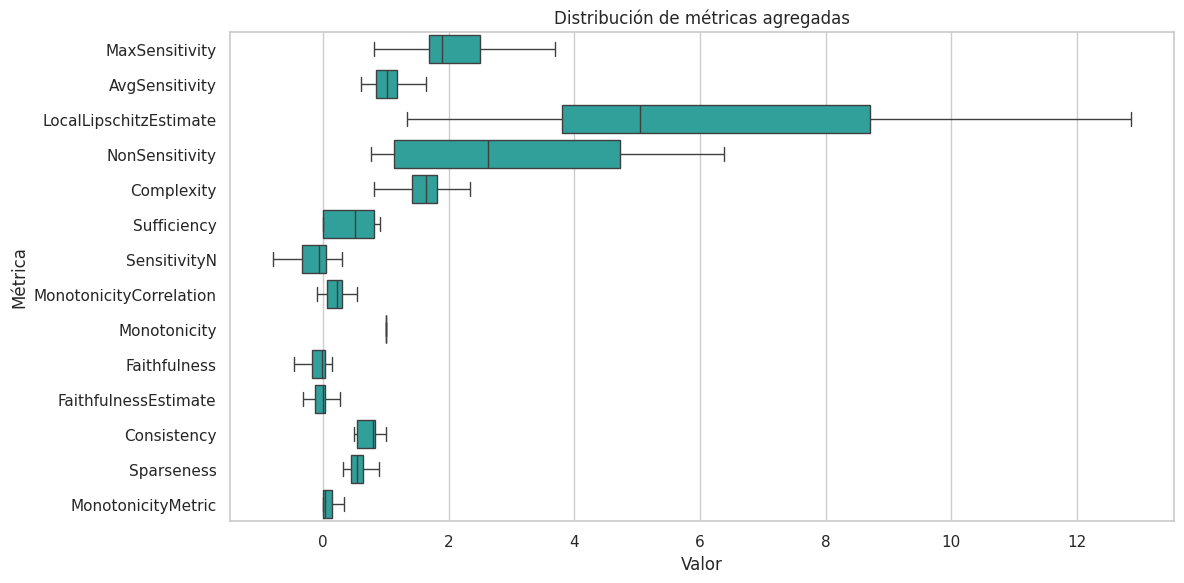

In [40]:
summary_plot_agg_aux = summary_plot_agg.drop(index=['RelativeOutputStability', 'RelativeInputStability'])

plot_long_agg = analysis_agg_df[summary_plot_agg_aux.index].melt(
    var_name="metric",
    value_name="value"
).dropna()


plt.figure(figsize=(12, 6))
sns.boxplot(
    data=plot_long_agg,
    x="value",
    y="metric",
    color="lightseagreen",
    showfliers=False
)
plt.title("Distribución de métricas agregadas")
plt.xlabel("Valor")
plt.ylabel("Métrica")
plt.tight_layout()
plt.savefig(results_dir / "agg_metric_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

## Correlación entre métricas

In [41]:
valid_metric_cols_agg = [
    c for c in metric_cols_agg
    if analysis_agg_df[c].dropna().nunique() > 1
]

excluded_constant_agg = [
    c for c in metric_cols_agg
    if c not in valid_metric_cols_agg
]

print("Métricas excluidas por ser constantes o no tener variación:")
print(excluded_constant_agg)

X_agg = analysis_agg_df[valid_metric_cols_agg]

corr_agg = X_agg.corr(
    method="spearman",
    min_periods=5
)

corr_agg

Métricas excluidas por ser constantes o no tener variación:
['Completeness']


,AvgSensitivity,Complexity,Consistency,Faithfulness,FaithfulnessEstimate,LocalLipschitzEstimate,MaxSensitivity,Monotonicity,MonotonicityCorrelation,MonotonicityMetric,NonSensitivity,RelativeInputStability,RelativeOutputStability,SensitivityN,Sparseness,Sufficiency
AvgSensitivity,1.000000,-0.130328,0.007968,-0.187777,-0.082964,0.148358,0.681283,0.153259,0.095798,0.077152,0.437667,0.031627,0.261727,-0.169748,0.275172,-0.201915
Complexity,-0.130328,1.000000,-0.340432,0.117889,0.519434,0.085457,-0.291317,0.169307,-0.273616,-0.053532,0.012750,-0.299312,-0.431016,0.282111,-0.567053,0.445958
Consistency,0.007968,-0.340432,1.000000,-0.292297,-0.137050,-0.228159,0.063347,-0.392889,0.239774,-0.627209,0.048815,0.007049,0.352285,-0.037553,0.341723,0.095918
Faithfulness,-0.187777,0.117889,-0.292297,1.000000,0.373745,-0.272329,-0.007003,0.227356,-0.002831,0.091522,-0.148625,-0.096715,-0.198472,0.107079,-0.045045,0.038264
FaithfulnessEstimate,-0.082964,0.519434,-0.137050,0.373745,1.000000,-0.167825,-0.040056,0.072560,-0.100386,0.028028,-0.170391,-0.116883,-0.022765,0.422909,-0.293951,0.312306
LocalLipschitzEstimate,0.148358,0.085457,-0.228159,-0.272329,-0.167825,1.000000,-0.244538,0.091910,0.000515,0.208150,0.099298,0.458518,0.032850,-0.044273,-0.268211,0.033817
MaxSensitivity,0.681283,-0.291317,0.063347,-0.007003,-0.040056,-0.244538,1.000000,0.333486,-0.033894,0.129737,0.268115,-0.110160,0.066157,-0.088235,0.388796,-0.271516
Monotonicity,0.153259,0.169307,-0.392889,0.227356,0.072560,0.091910,0.333486,1.000000,-0.198332,0.329518,0.091975,-0.237816,-0.470347,0.111259,-0.217681,0.025320
MonotonicityCorrelation,0.095798,-0.273616,0.239774,-0.002831,-0.100386,0.000515,-0.033894,-0.198332,1.000000,-0.303125,-0.102647,-0.202445,0.155691,-0.057400,0.172716,0.032066
MonotonicityMetric,0.077152,-0.053532,-0.627209,0.091522,0.028028,0.208150,0.129737,0.329518,-0.303125,1.000000,-0.278948,0.230353,-0.082505,-0.207751,-0.177864,-0.170484


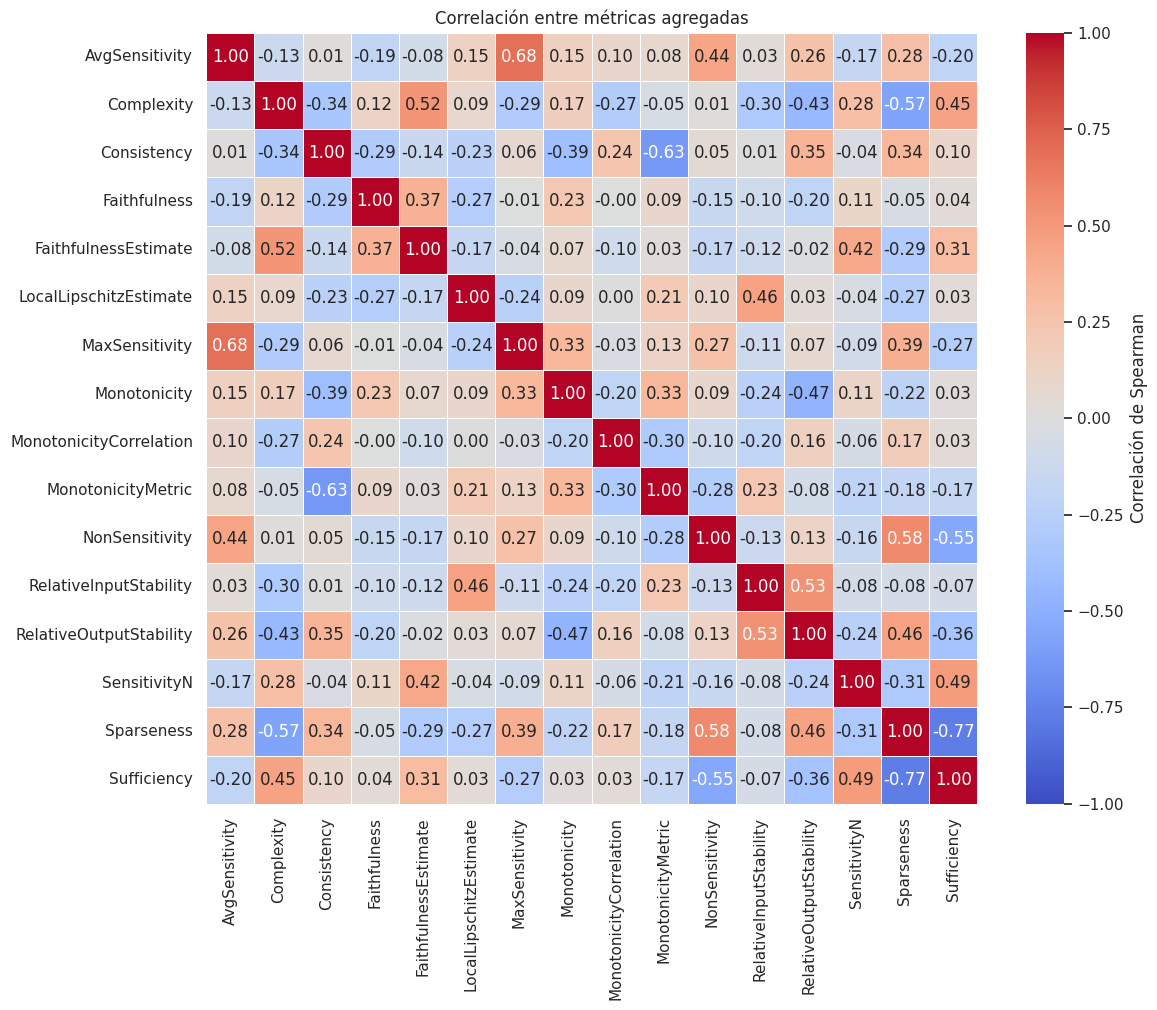

In [42]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_agg,
    vmin=-1,
    vmax=1,
    center=0,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Correlación de Spearman"}
)

plt.title("Correlación entre métricas agregadas")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(results_dir / "agg_correlation_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

In [43]:
corr_pairs_agg = (
    corr_agg.where(
        np.triu(np.ones(corr_agg.shape), k=1).astype(bool)
    )
    .stack()
    .reset_index()
)

corr_pairs_agg.columns = ["metric_1", "metric_2", "spearman_corr"]
corr_pairs_agg["abs_corr"] = corr_pairs_agg["spearman_corr"].abs()

strong_corr_agg = corr_pairs_agg[
    corr_pairs_agg["abs_corr"] > 0.7
].sort_values("abs_corr", ascending=False)

strong_corr_agg

,metric_1,metric_2,spearman_corr,abs_corr
119,Sparseness,Sufficiency,-0.772276,0.772276


## Clustering jerárquico de métricas

In [44]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

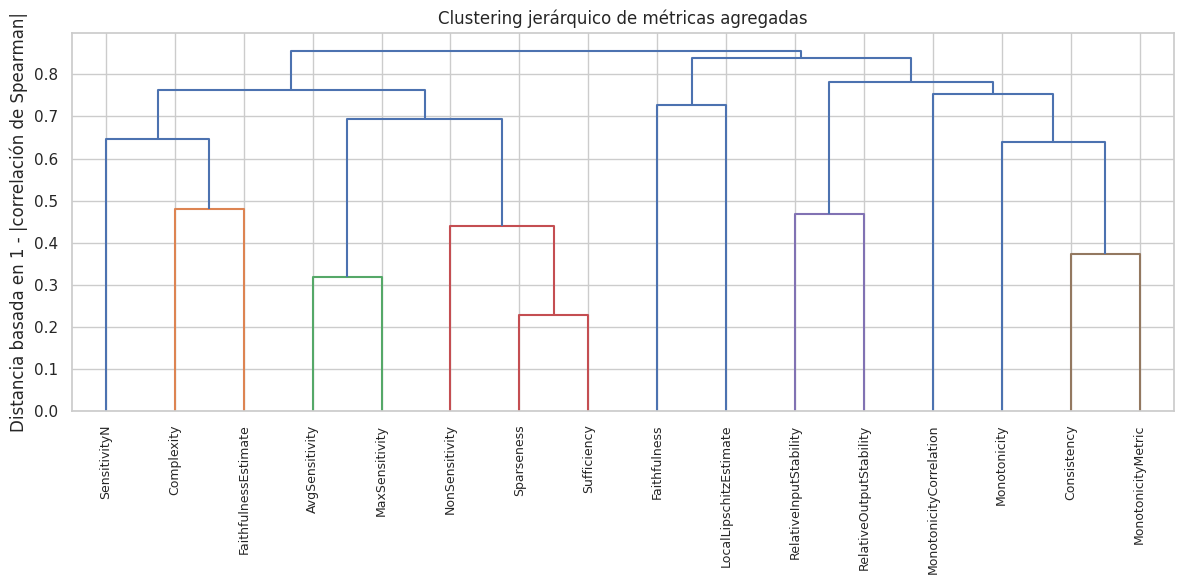

In [45]:
corr_cluster_agg = corr_agg.copy()

corr_cluster_agg = corr_cluster_agg.dropna(axis=0, how="all").dropna(axis=1, how="all")

valid_metrics_agg = corr_cluster_agg.index.intersection(corr_cluster_agg.columns)
corr_cluster_agg = corr_cluster_agg.loc[valid_metrics_agg, valid_metrics_agg]

corr_cluster_agg = corr_cluster_agg.fillna(0)

distance_agg = 1 - corr_cluster_agg.abs()
np.fill_diagonal(distance_agg.values, 0)

linkage_matrix_agg = linkage(
    squareform(distance_agg),
    method="average"
)

plt.figure(figsize=(12, 6))

dendrogram(
    linkage_matrix_agg,
    labels=corr_cluster_agg.columns,
    leaf_rotation=90,
    leaf_font_size=9
)

plt.title("Clustering jerárquico de métricas agregadas")
plt.ylabel("Distancia basada en 1 - |correlación de Spearman|")
plt.tight_layout()
plt.savefig(results_dir / "agg_dendrogram_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

## Influencia de dataset, modelo y método XAI

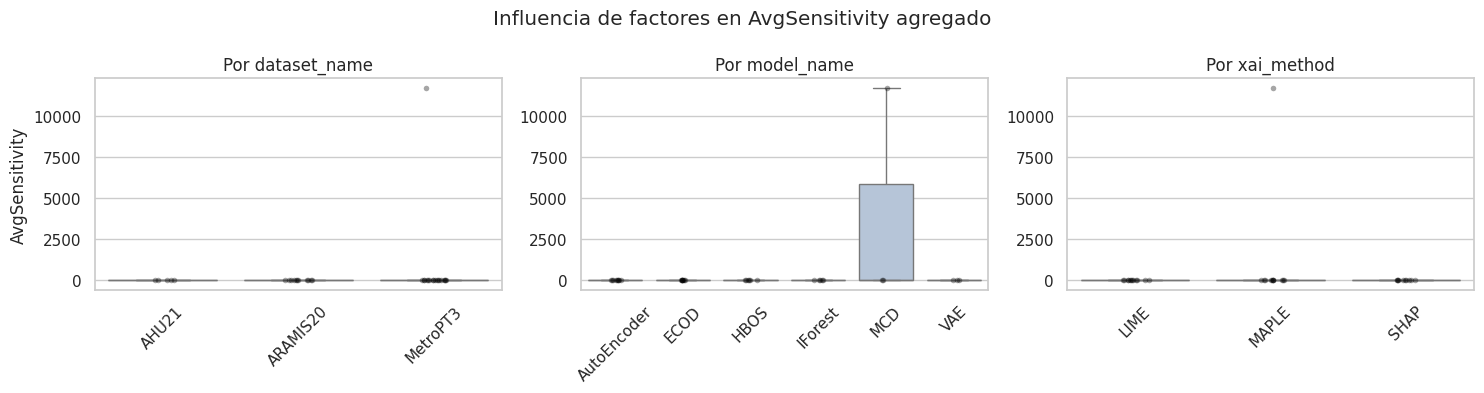

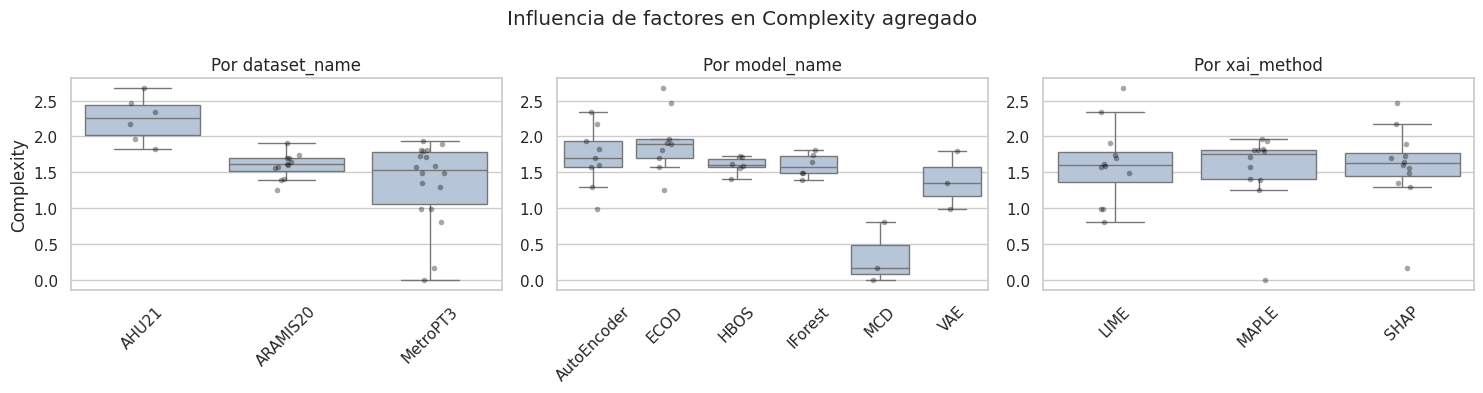

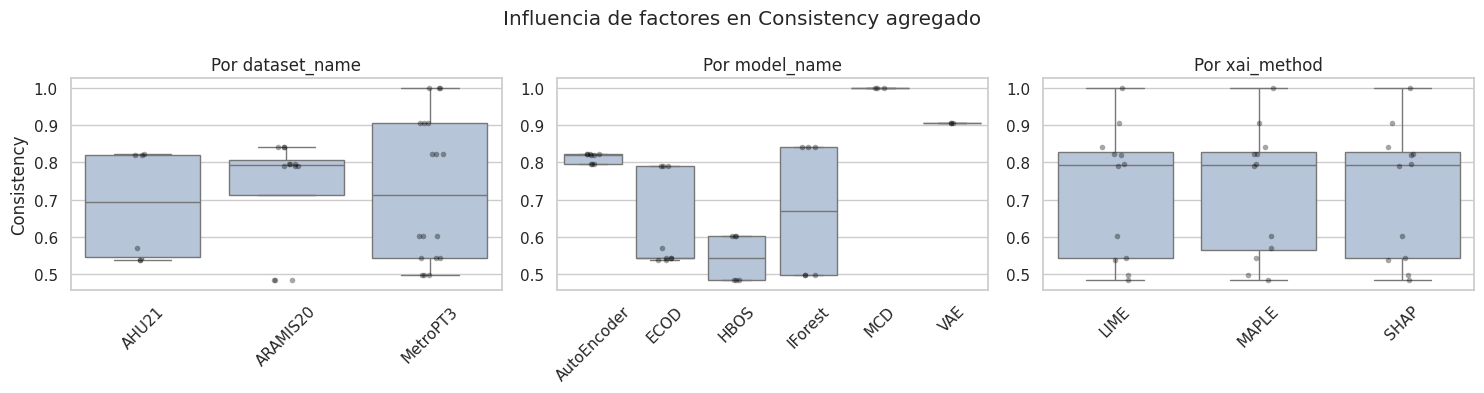

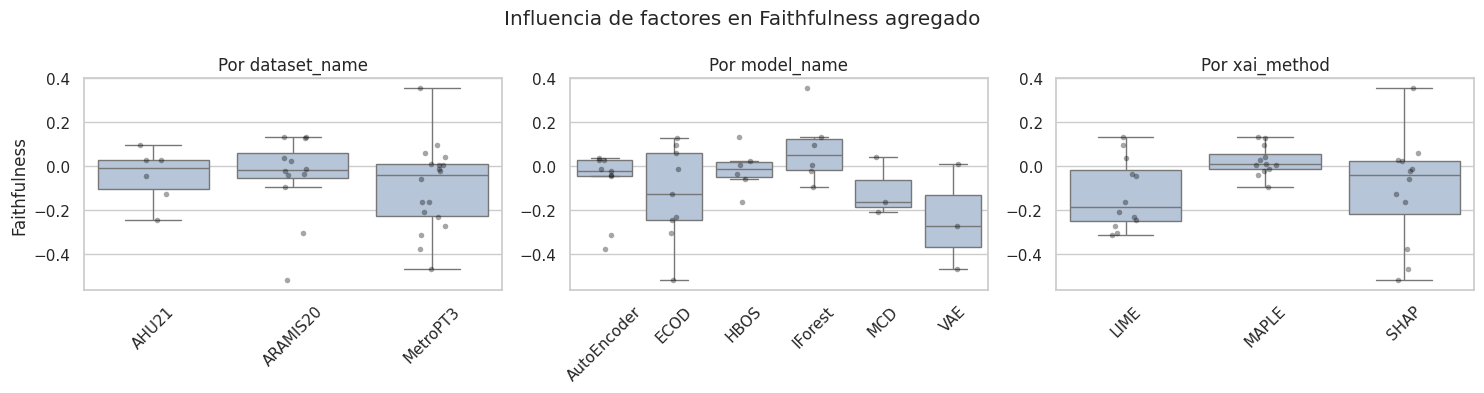

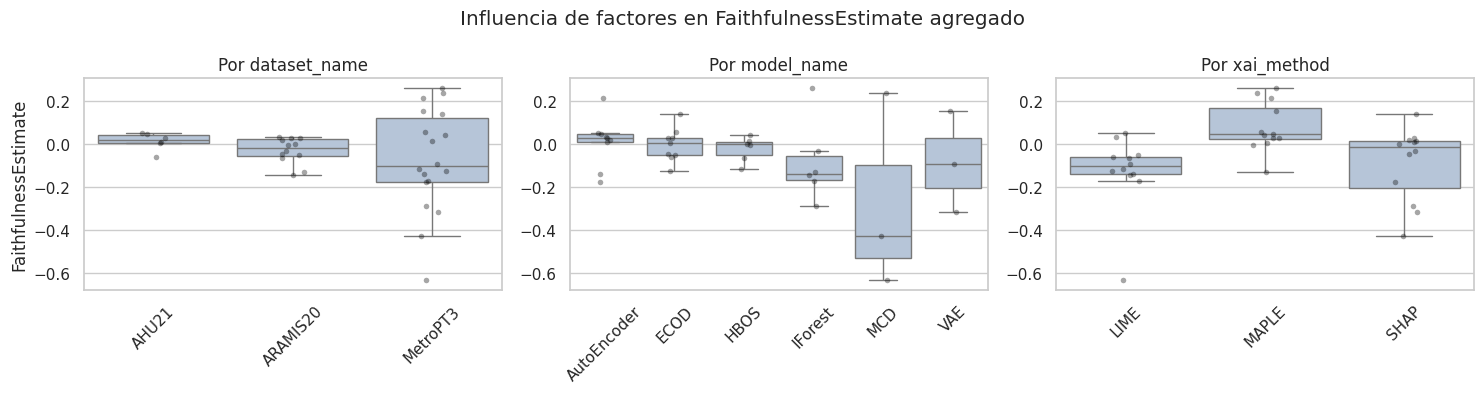

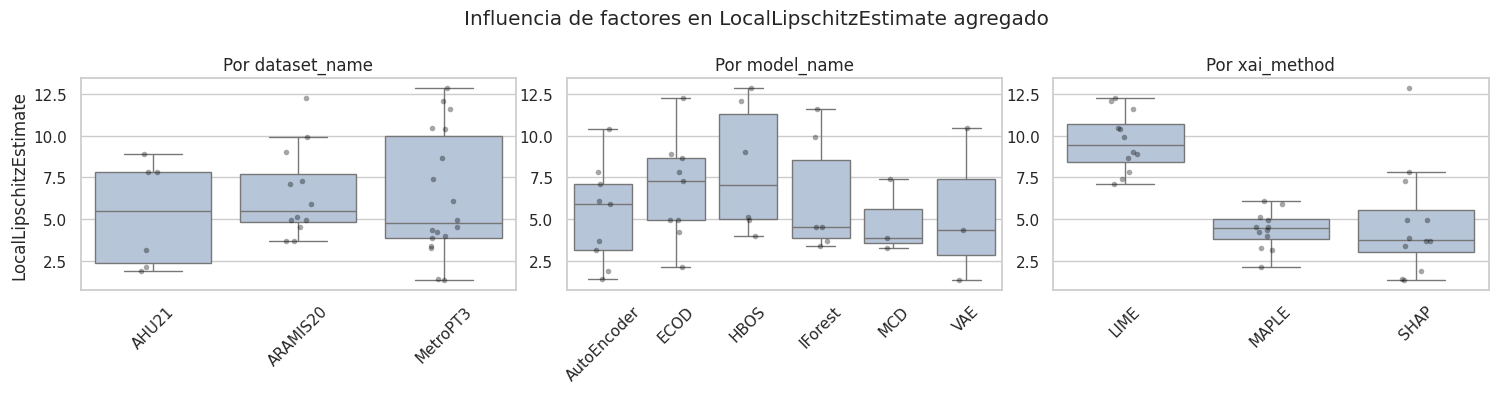

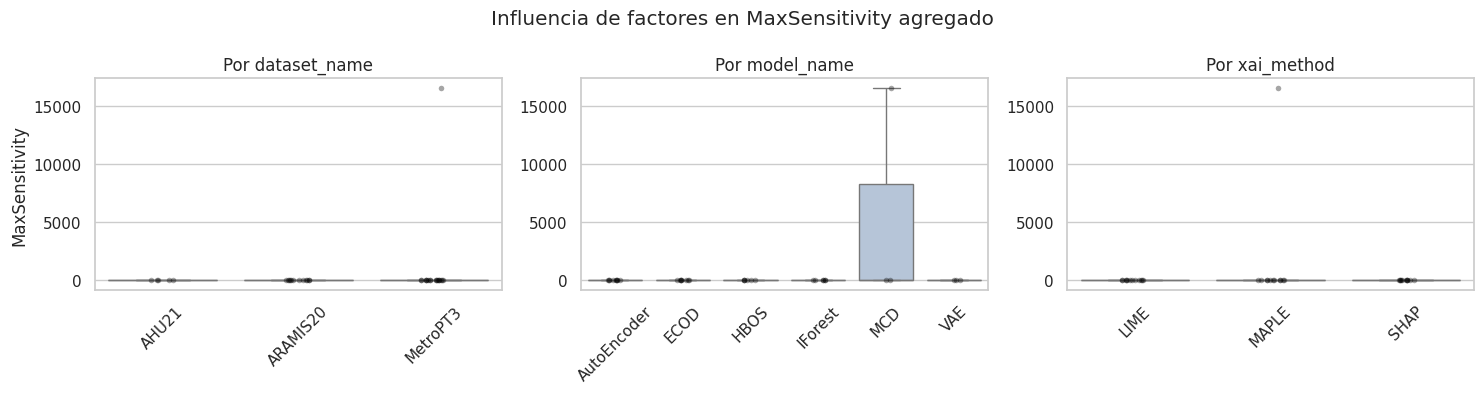

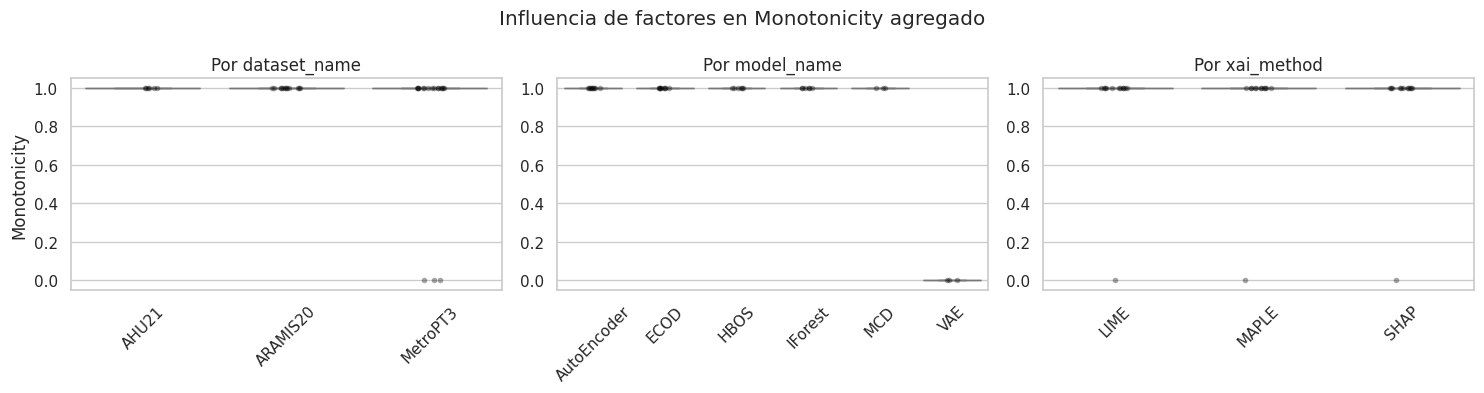

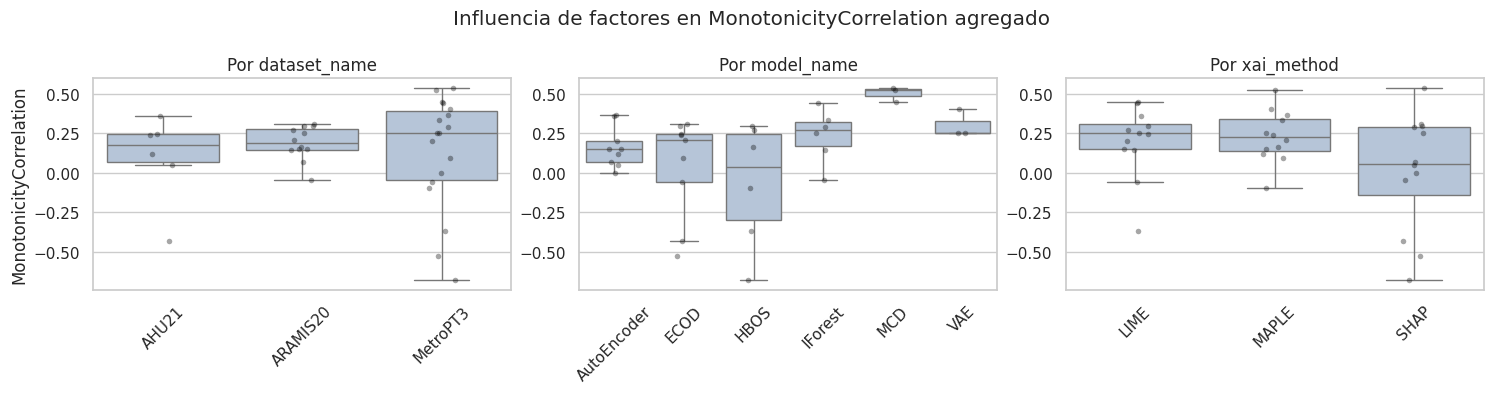

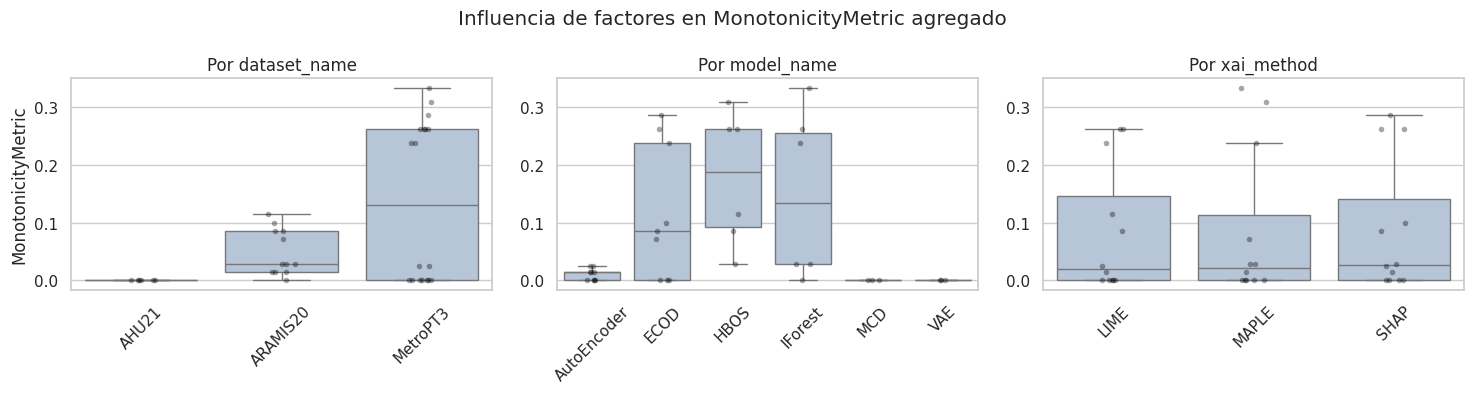

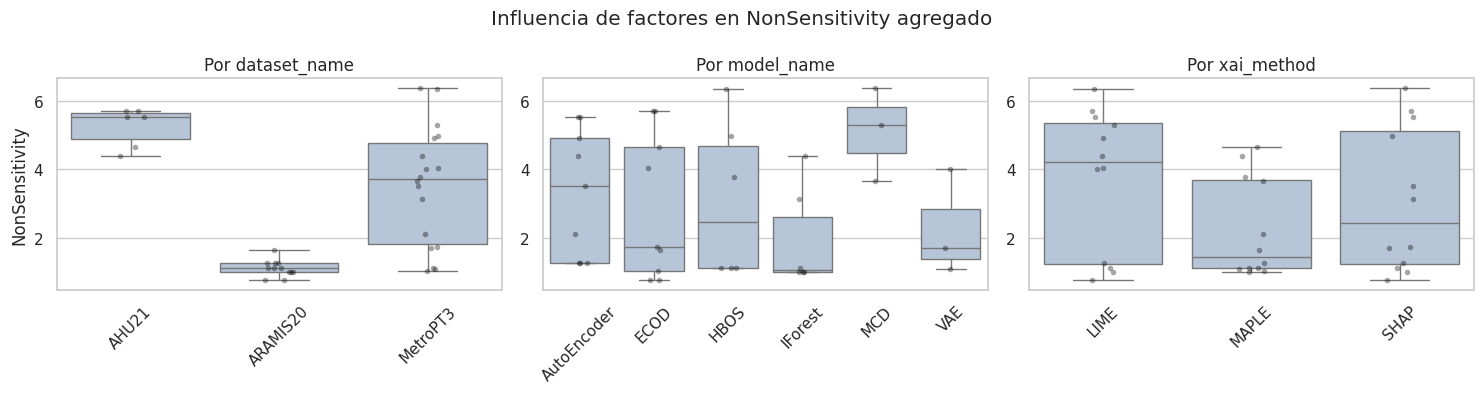

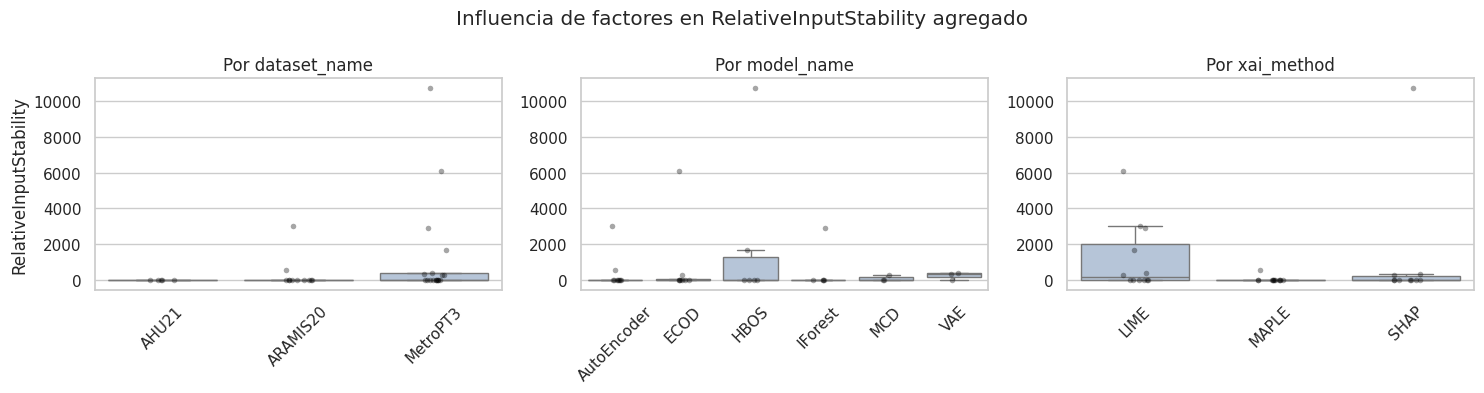

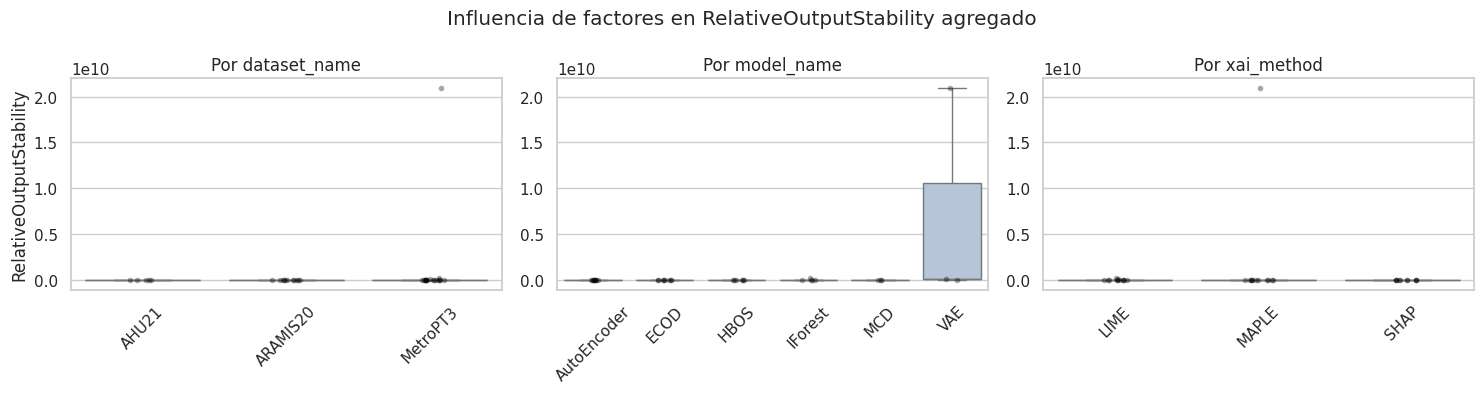

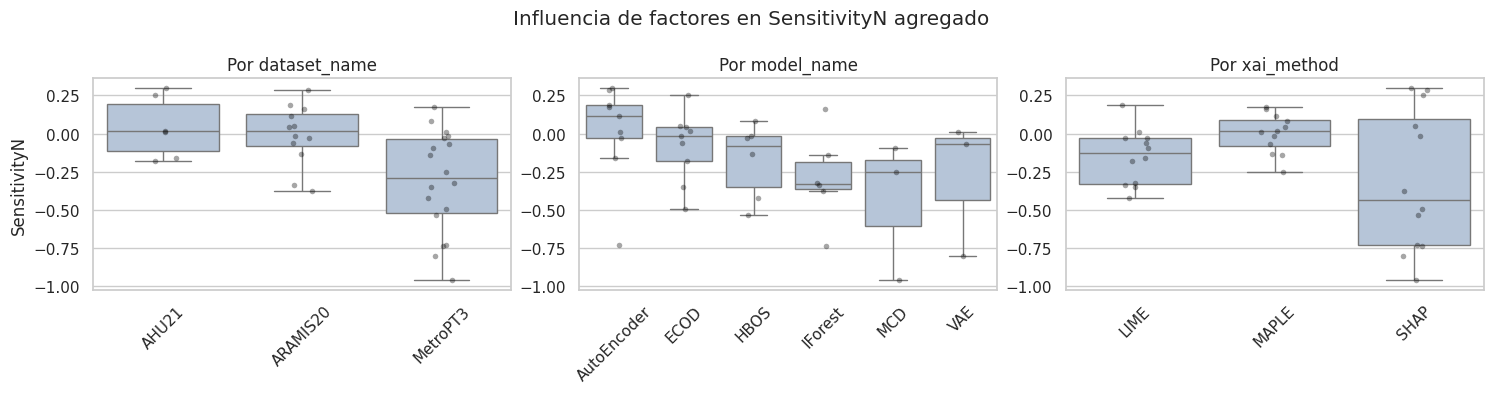

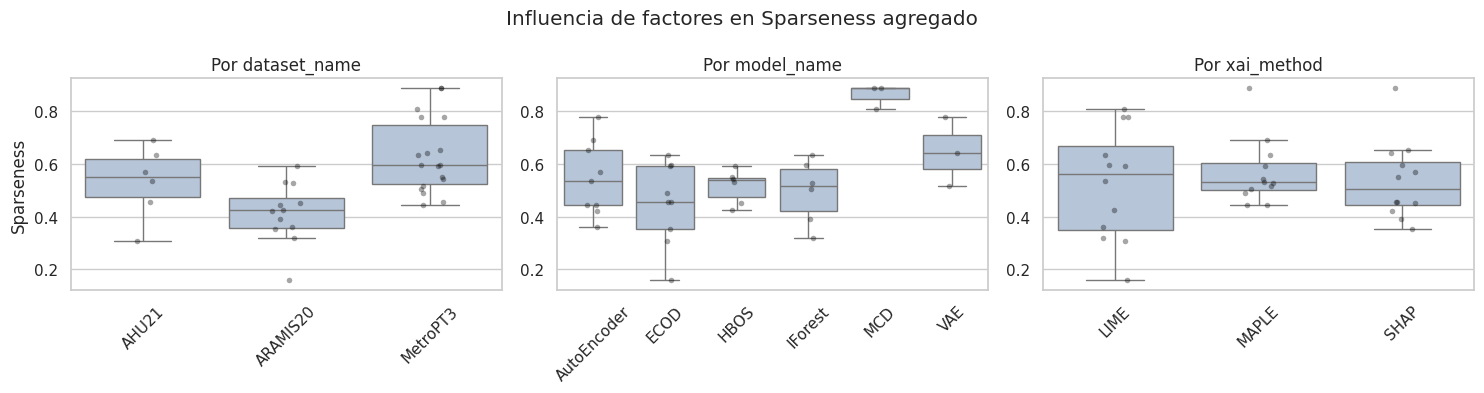

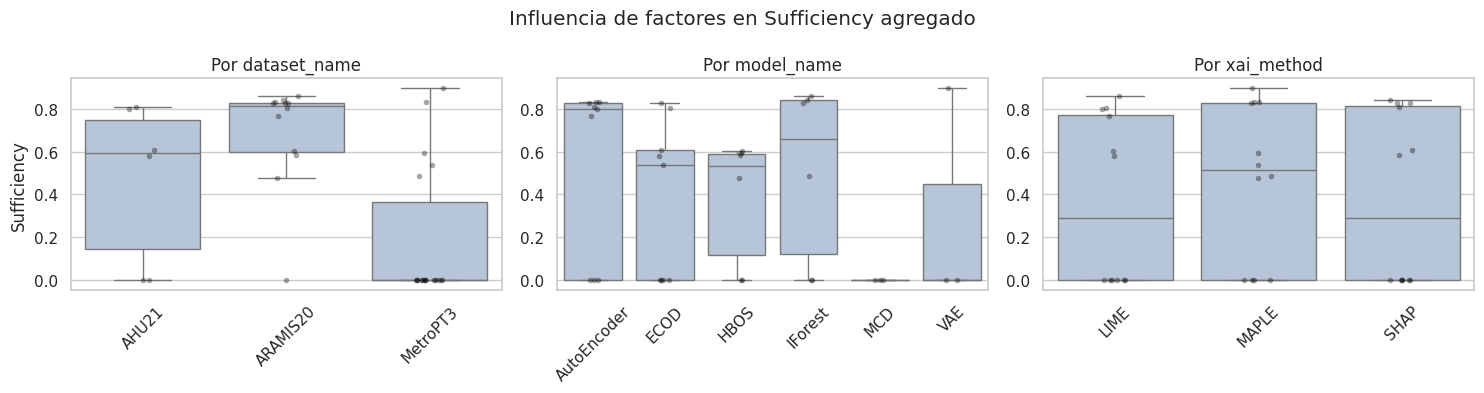

In [46]:
factors_agg = ["dataset_name", "model_name", "xai_method"]

selected_metrics_agg = [
    c for c in valid_metric_cols_agg
    if analysis_agg_df[c].dropna().nunique() > 1
]

for metric in selected_metrics_agg:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for ax, factor in zip(axes, factors_agg):
        plot_df = analysis_agg_df[[factor, metric]].dropna()

        sns.boxplot(
            data=plot_df,
            x=factor,
            y=metric,
            ax=ax,
            color="lightsteelblue",
            showfliers=False
        )

        sns.stripplot(
            data=plot_df,
            x=factor,
            y=metric,
            ax=ax,
            color="black",
            alpha=0.35,
            size=4,
            jitter=True
        )

        ax.set_title(f"Por {factor}")
        ax.set_xlabel("")
        ax.set_ylabel(metric if factor == factors_agg[0] else "")
        ax.tick_params(axis="x", rotation=45)

    fig.suptitle(f"Influencia de factores en {metric} agregado")
    plt.tight_layout()
    plt.savefig(results_dir / f"agg_{metric}_factors_boxplots.png", dpi=300, bbox_inches="tight")
    plt.show()

In [47]:
kruskal_results_agg = []

for metric in selected_metrics_agg:
    for factor in factors_agg:
        groups = [
            group[metric].dropna().values
            for _, group in analysis_agg_df.groupby(factor)
        ]

        groups = [g for g in groups if len(g) > 0]

        if len(groups) > 1:
            stat, p_value = kruskal(*groups)

            kruskal_results_agg.append({
                "metric": metric,
                "factor": factor,
                "H": stat,
                "p_value": p_value,
                "significant_0.05": p_value < 0.05
            })

kruskal_agg_df = pd.DataFrame(kruskal_results_agg)

kruskal_agg_df = kruskal_agg_df.sort_values(
    ["p_value", "metric", "factor"],
    ascending=[True, True, True]
)

kruskal_agg_df

,metric,factor,H,p_value,significant_0.05
22,Monotonicity,model_name,35.000000,0.000002,True
30,NonSensitivity,dataset_name,20.309282,0.000039,True
17,LocalLipschitzEstimate,xai_method,18.740240,0.000085,True
7,Consistency,model_name,23.559783,0.000264,True
36,RelativeOutputStability,dataset_name,15.711362,0.000388,True
42,Sparseness,dataset_name,14.461712,0.000724,True
3,Complexity,dataset_name,13.876126,0.000970,True
14,FaithfulnessEstimate,xai_method,11.947447,0.002545,True
33,RelativeInputStability,dataset_name,11.763555,0.002790,True
45,Sufficiency,dataset_name,11.663170,0.002933,True
